In [1]:
import numpy as np
import matplotlib.pyplot as plt
from regions import Regions
import regions
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord 
from astropy import units as u
from astropy.modeling import models, fitting
 
from dust_extinction.averages import CT06_MWGC 

from smart_plotters.jwst_plots import JWSTCatalog, make_cat_use, make_brick_cat
from smart_plotters.cutout_plot import get_cutout_405, get_cutout_jwst_ice
import smart_plotters.co_ice as co_map
from icemodels.colorcolordiagrams import plot_ccd_icemodels
from smart_plotters import cmd_plot 
from sklearn.mixture import GaussianMixture
from mpl_plot_templates import adaptive_param_plot
from scipy.optimize import curve_fit 
from scipy.signal import find_peaks, argrelextrema

from spectral_cube import SpectralCube

        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]
/blue/adamginsburg/adamginsburg/repos/jwst-gc-pipeline/jwst_gc_pipeline/plotting/plot_tools.py:788: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f'{filtername} $\mu$={np.median(sep).to(u.marcsec).value:0.1f} $\sigma$={np.std(sep).to(u.marcsec).value:0.1f}', fontsize=10)
/blue/adamginsburg/adamginsburg/repos/jwst-gc-pipeline/jwst_gc_pipeline/plotting/plot_tools.py:788: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f'{filtername} $\mu$={np.median(sep).to(u.marcsec).value:0.1f} $\sigma$={np.std(sep).to(u.marcsec).value:0.1f}', fontsize=10)
        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]
**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-072 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-073
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


In [2]:
reg_f = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/filament_short.region')
reg_b = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/cloudb.region')
reg_c1 = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/cloudc1_ice.reg')
reg_c2 = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/cloudc2_ice.reg')
reg_d = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/cloudd_ice.reg')
reg_fil_r = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/filament_right.region')
reg_left_cd = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/left_cloudd.region')
reg_c_n = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/cloudc_north.region')
reg_c_s = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/cloudc_south.region')

regions_cloudc = [reg_f, reg_b, reg_c1, reg_c2, reg_d, reg_fil_r, reg_left_cd, reg_c_n, reg_c_s]
labels_cloudc = ['Filament', 'Cloud C1', 'Cloud C2', 'Cloud D', 'Cloud B', 'Filament Right', 'Left Cloud D', 'Cloud C North', 'Cloud C South']


In [3]:
reg_brick_north = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_north.reg')
reg_brick_south = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_south.reg')
reg_brick_head = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_head.reg')
reg_brick_sfluff = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfluff.reg')
reg_brick_nfluff = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_nfluff.reg')
reg_brick_sfr = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr_tight.reg')
reg_brick_sfrwide = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr.reg')
reg_brick_punch = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_punch.reg')
reg_brick_sfore = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfore.reg')
reg_brick_nclear = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_nclear.reg')
reg_brick_topc = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_topc.reg')

regions_brick = [reg_brick_north, reg_brick_south, reg_brick_head, reg_brick_sfluff, reg_brick_nfluff, reg_brick_sfr, reg_brick_sfrwide, reg_brick_punch, reg_brick_sfore, reg_brick_nclear, reg_brick_topc]
labels_brick = ['Brick North', 'Brick South', 'Brick Head', 'Brick South Fluff', 'Brick North Fluff', 'Brick SFR', 'Brick SFR Wide', 'Brick Punch', 'Brick S Fore', 'Brick N Clear', 'Brick Top C']


In [4]:
fn_HNCO = '/orange/adamginsburg/ACES/mosaics/cubes/HNCO_7m12mTP_CubeMosaic_downsampled9.fits'
#HNCO_7m12mTP_CubeMosaic.fits'
cube_HNCO = SpectralCube.read(fn_HNCO)
cube_HNCO = cube_HNCO.spectral_slab(-100*u.km/u.s, 100*u.km/u.s)

In [5]:
fn_CS = '/orange/adamginsburg/ACES/mosaics/cubes/CS21_CubeMosaic_downsampled9.fits'
cube_CS = SpectralCube.read(fn_CS)
cube_CS = cube_CS.spectral_slab(-100*u.km/u.s, 100*u.km/u.s)

In [6]:
#fn_SiO = '/orange/adamginsburg/ACES/mosaics/cubes/SiO21_CubeMosaic_downsampled9.fits'
#cube_SiO = SpectralCube.read(fn_SiO)
#cube_SiO = cube_SiO.spectral_slab(-100*u.km/u.s, 100*u.km/u.s)

# HNCO Spectra of each region

In [7]:
def noise_mask(cube, vmin, vmax, level):
    noise = cube.with_spectral_unit(u.km/u.s, velocity_convention='radio').spectral_slab(vmin, vmax).std(axis=0)
    peak = cube.max(axis=0)
    spatial_mask = peak > level * noise
    return spatial_mask

def noise_mask_slab(cube, vmin, vmax, level, cut1, cut2):
    noise = cube.with_spectral_unit(u.km/u.s, velocity_convention='radio').spectral_slab(vmin, vmax).std(axis=0)
    peak = cube.spectral_slab(cut1, cut2).max(axis=0)
    spatial_mask = peak > level * noise
    return spatial_mask

def get_x(mom0):
    ww = wcs.WCS(mom0.header)
    pixelarea = ww.proj_plane_pixel_area()#.to(u.sr)
    #np.sqrt(pixelarea.to(u.rad**2)).to(u.arcsecond)
    x = range(mom0.shape[1]) * np.sqrt(pixelarea.to(u.rad**2)).to(u.arcmin)
    return x

## Cloud C

### Filament

In [8]:
# Filament
cube_f_HNCO = cube_HNCO.subcube_from_regions(reg_f, minimize=False)
#mask_f_HNCO = noise_mask(cube_f_HNCO, -70*u.km/u.s, -40*u.km/u.s, 3)
#cube_f_HNCO = cube_f_HNCO.spectral_slab(-70*u.km/u.s, -40*u.km/u.s)
cube_f_HNCO.allow_huge_operations = True
spec_f_HNCO = cube_f_HNCO.mean(axis=(1,2))
cube_f_CS = cube_CS.subcube_from_regions(reg_f, minimize=False)
#cube_f_CS = cube_f_CS.spectral_slab(-70*u.km/u.s, -40*u.km/u.s)
cube_f_CS.allow_huge_operations = True
spec_f_CS = cube_f_CS.mean(axis=(1,2))
#cube_f_SiO = cube_SiO.subcube_from_regions(reg_f, minimize=False)
##cube_f_SiO = cube_f_SiO.spectral_slab(-70*u.km/u.s, -40*u.km/u.s)
#cube_f_SiO.allow_huge_operations = True
#spec_f_SiO = cube_f_SiO.mean(axis=(1,2))

/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: Mean of empty slice
  out = function(self._get_filled_data(fill=fill,


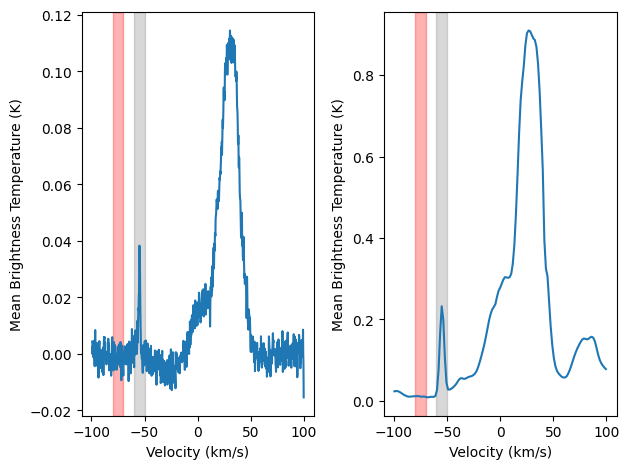

In [9]:
ax1 = plt.subplot(121)
ax1.plot(spec_f_HNCO.spectral_axis, spec_f_HNCO.value, label='HNCO')
ax1.set_xlabel('Velocity (km/s)')
ax1.set_ylabel('Mean Brightness Temperature (K)')

ax2 = plt.subplot(122)
ax2.plot(spec_f_CS.spectral_axis, spec_f_CS.value, label='CS')
ax2.set_xlabel('Velocity (km/s)')
ax2.set_ylabel('Mean Brightness Temperature (K)')

for ax in [ax1, ax2]:
    ax.axvspan(-60, -50, color='gray', alpha=0.3)
    ax.axvspan(-80, -70, color='red', alpha=0.3)

plt.tight_layout()

In [10]:
mask_f_HNCO = noise_mask(cube_f_HNCO, -80*u.km/u.s, -70*u.km/u.s, 5)
mask_f_CS = noise_mask(cube_f_CS, -80*u.km/u.s, -70*u.km/u.s, 5)

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,


In [11]:
cube_f_HNCO_range = cube_f_HNCO.spectral_slab(-60*u.km/u.s, -50*u.km/u.s)
cube_f_CS_range = cube_f_CS.spectral_slab(-60*u.km/u.s, -50*u.km/u.s)

mom0_f_HNCO = cube_f_HNCO_range.with_mask(mask_f_HNCO).moment(order=0)
mom0_f_CS = cube_f_CS_range.with_mask(mask_f_CS).moment(order=0)

ratio_f_HNCO_CS = mom0_f_HNCO / mom0_f_CS

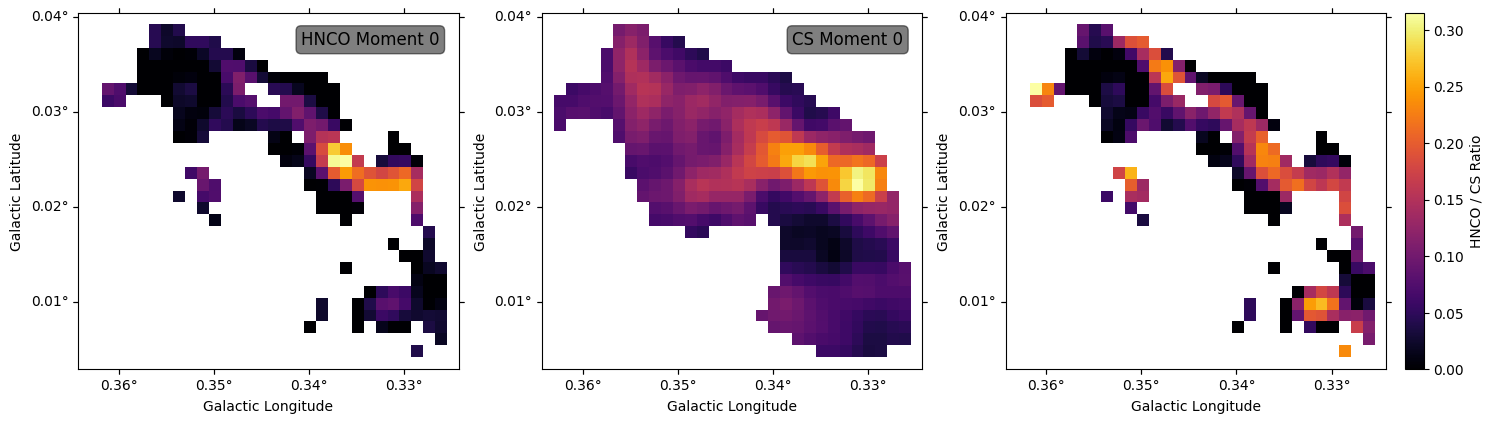

In [12]:
fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_f_HNCO.wcs)
ax1.imshow(mom0_f_HNCO.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.95, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_f_CS.wcs)
ax2.imshow(mom0_f_CS.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.95, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_f_HNCO_CS.wcs)
im = ax3.imshow(ratio_f_HNCO_CS.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical', label='HNCO / CS Ratio')

plt.tight_layout()

### Cloud C1

In [13]:
# Cloud C1 
cube_c1_HNCO = cube_HNCO.subcube_from_regions(reg_c1, minimize=False)
spec_c1_HNCO = cube_c1_HNCO.mean(axis=(1, 2))
cube_c1_CS = cube_CS.subcube_from_regions(reg_c1, minimize=False)
spec_c1_CS = cube_c1_CS.mean(axis=(1, 2))
#cube_c1_SiO = cube_SiO.subcube_from_regions(reg_c1, minimize=False)
#spec_c1_SiO = cube_c1_SiO.mean(axis=(1, 2))

/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: Mean of empty slice
  out = function(self._get_filled_data(fill=fill,


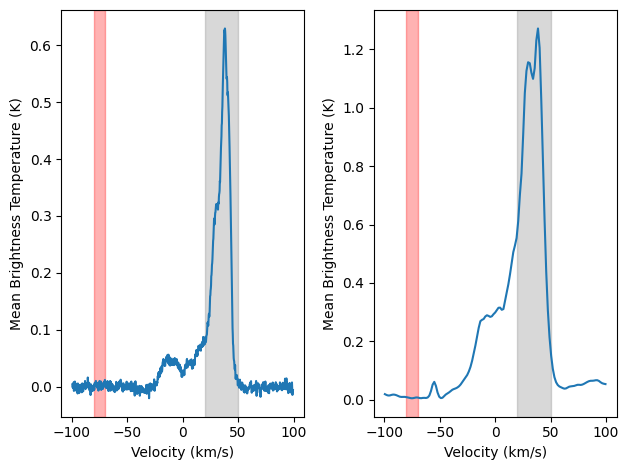

In [14]:
ax1 = plt.subplot(121)
ax1.plot(spec_c1_HNCO.spectral_axis, spec_c1_HNCO.value, label='HNCO')
ax1.set_xlabel('Velocity (km/s)')
ax1.set_ylabel('Mean Brightness Temperature (K)')

ax2 = plt.subplot(122)
ax2.plot(spec_c1_CS.spectral_axis, spec_c1_CS.value, label='CS')
ax2.set_xlabel('Velocity (km/s)')
ax2.set_ylabel('Mean Brightness Temperature (K)')

for ax in [ax1, ax2]:
    ax.axvspan(20, 50, color='gray', alpha=0.3)
    ax.axvspan(-80, -70, color='red', alpha=0.3)

plt.tight_layout()

In [15]:
mask_c1_HNCO = noise_mask(cube_c1_HNCO, -80*u.km/u.s, -70*u.km/u.s, 5)
mask_c1_CS = noise_mask(cube_c1_CS, -80*u.km/u.s, -70*u.km/u.s, 5)

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,


In [16]:
cube_c1_HNCO_range = cube_c1_HNCO.spectral_slab(20*u.km/u.s, 50*u.km/u.s)
cube_c1_CS_range = cube_c1_CS.spectral_slab(20*u.km/u.s, 50*u.km/u.s)

mom0_c1_HNCO = cube_c1_HNCO_range.with_mask(mask_c1_HNCO).moment(order=0)
mom0_c1_CS = cube_c1_CS_range.with_mask(mask_c1_CS).moment(order=0)

ratio_c1_HNCO_CS = mom0_c1_HNCO / mom0_c1_CS

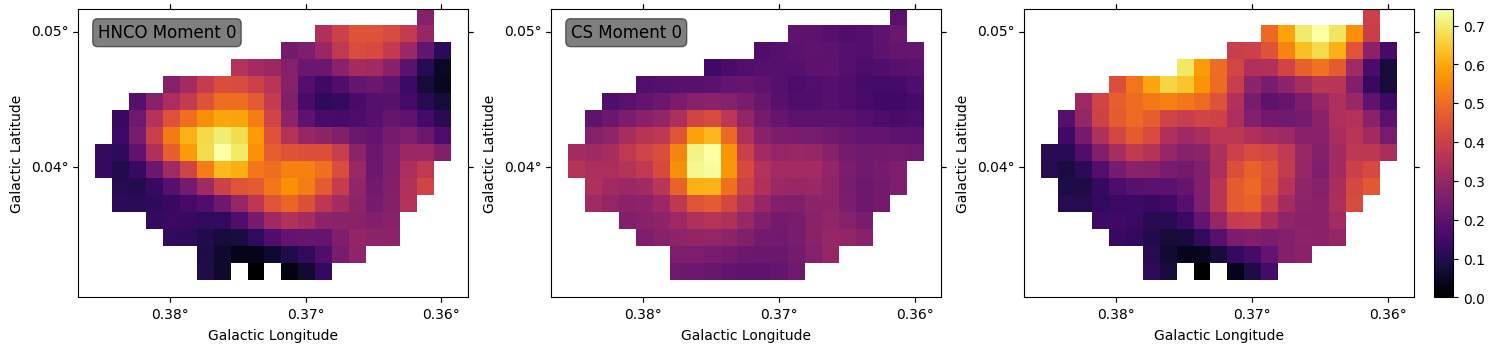

In [17]:
fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_c1_HNCO.wcs)
ax1.imshow(mom0_c1_HNCO.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.05, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_c1_CS.wcs)
ax2.imshow(mom0_c1_CS.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.05, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_c1_HNCO_CS.wcs)
im = ax3.imshow(ratio_c1_HNCO_CS.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

### Cloud C2

In [18]:
# Cloud C2
cube_c2_HNCO = cube_HNCO.subcube_from_regions(reg_c2, minimize=False)
spec_c2_HNCO = cube_c2_HNCO.mean(axis=(1, 2))
cube_c2_CS = cube_CS.subcube_from_regions(reg_c2, minimize=False)
spec_c2_CS = cube_c2_CS.mean(axis=(1, 2))
#cube_c2_SiO = cube_SiO.subcube_from_regions(reg_c2, minimize=False)
#spec_c2_SiO = cube_c2_SiO.mean(axis=(1, 2))

/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: Mean of empty slice
  out = function(self._get_filled_data(fill=fill,


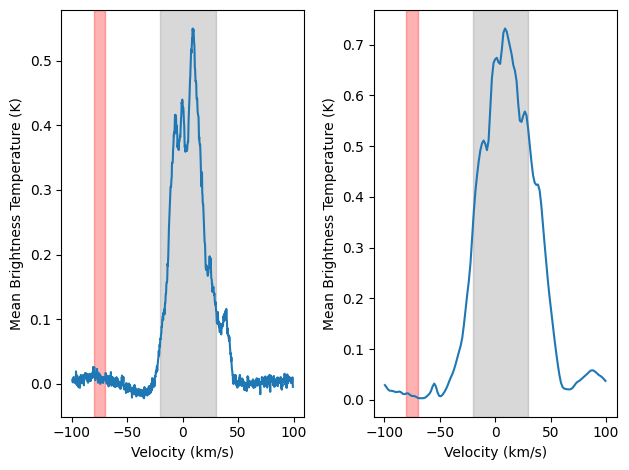

In [19]:
ax1 = plt.subplot(121)
ax1.plot(spec_c2_HNCO.spectral_axis, spec_c2_HNCO.value, label='HNCO')
ax1.set_xlabel('Velocity (km/s)')
ax1.set_ylabel('Mean Brightness Temperature (K)')

ax2 = plt.subplot(122)
ax2.plot(spec_c2_CS.spectral_axis, spec_c2_CS.value, label='CS')
ax2.set_xlabel('Velocity (km/s)')
ax2.set_ylabel('Mean Brightness Temperature (K)')

for ax in [ax1, ax2]:
    ax.axvspan(-20, 30, color='gray', alpha=0.3)
    ax.axvspan(-80, -70, color='red', alpha=0.3)
    #ax.axvspan(-15, -5, color='red', alpha=0.3)
    #ax.axvspan(-5, 3, color='blue', alpha=0.3)
    #ax.axvspan(3, 20, color='green', alpha=0.3)
    #ax.axvspan(20, 30, color='yellow', alpha=0.3)
    #ax.axvspan(30, 50, color='purple', alpha=0.3)

plt.tight_layout()


In [20]:
mask_c2_HNCO = noise_mask(cube_c2_HNCO, -80*u.km/u.s, -70*u.km/u.s, 5)
mask_c2_CS = noise_mask(cube_c2_CS, -80*u.km/u.s, -70*u.km/u.s, 5)

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,


In [21]:
cube_c2_HNCO_range = cube_c2_HNCO.spectral_slab(-20*u.km/u.s, 30*u.km/u.s)
cube_c2_CS_range = cube_c2_CS.spectral_slab(-20*u.km/u.s, 30*u.km/u.s)

mom0_c2_HNCO = cube_c2_HNCO_range.with_mask(mask_c2_HNCO).moment(order=0)
mom0_c2_CS = cube_c2_CS_range.with_mask(mask_c2_CS).moment(order=0)

ratio_c2_HNCO_CS = mom0_c2_HNCO / mom0_c2_CS

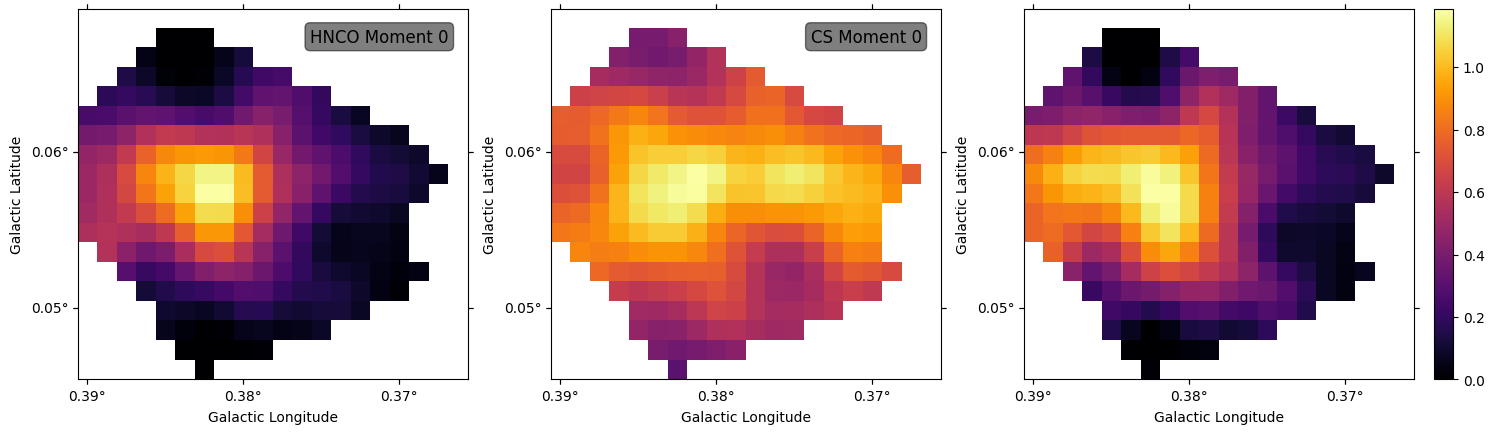

In [22]:
fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_c2_HNCO.wcs)
ax1.imshow(mom0_c2_HNCO.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.95, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_c2_CS.wcs)
ax2.imshow(mom0_c2_CS.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.95, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_c2_HNCO_CS.wcs)
im = ax3.imshow(ratio_c2_HNCO_CS.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

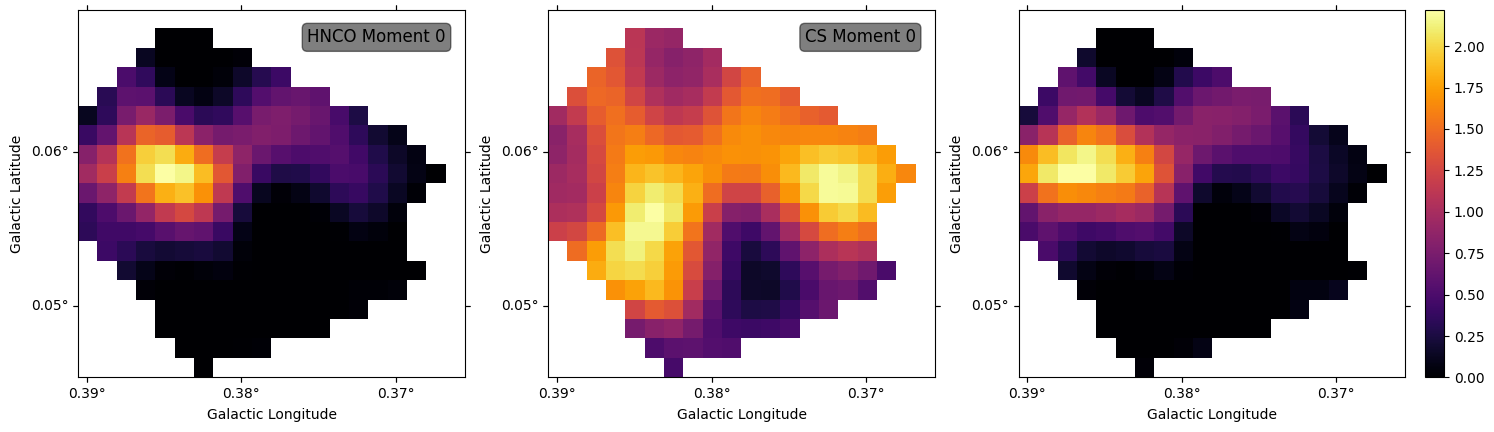

In [23]:
cube_c2_HNCO_range1 = cube_c2_HNCO.spectral_slab(-15*u.km/u.s, -5*u.km/u.s)
cube_c2_CS_range1 = cube_c2_CS.spectral_slab(-15*u.km/u.s, -5*u.km/u.s)
mom0_c2_HNCO_range1 = cube_c2_HNCO_range1.with_mask(mask_c2_HNCO).moment(order=0)
mom0_c2_CS_range1 = cube_c2_CS_range1.with_mask(mask_c2_CS).moment(order=0)
ratio_c2_HNCO_CS_range1 = mom0_c2_HNCO_range1 / mom0_c2_CS_range1

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_c2_HNCO_range1.wcs)
ax1.imshow(mom0_c2_HNCO_range1.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.95, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_c2_CS_range1.wcs)
ax2.imshow(mom0_c2_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.95, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_c2_HNCO_CS_range1.wcs)
im = ax3.imshow(ratio_c2_HNCO_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

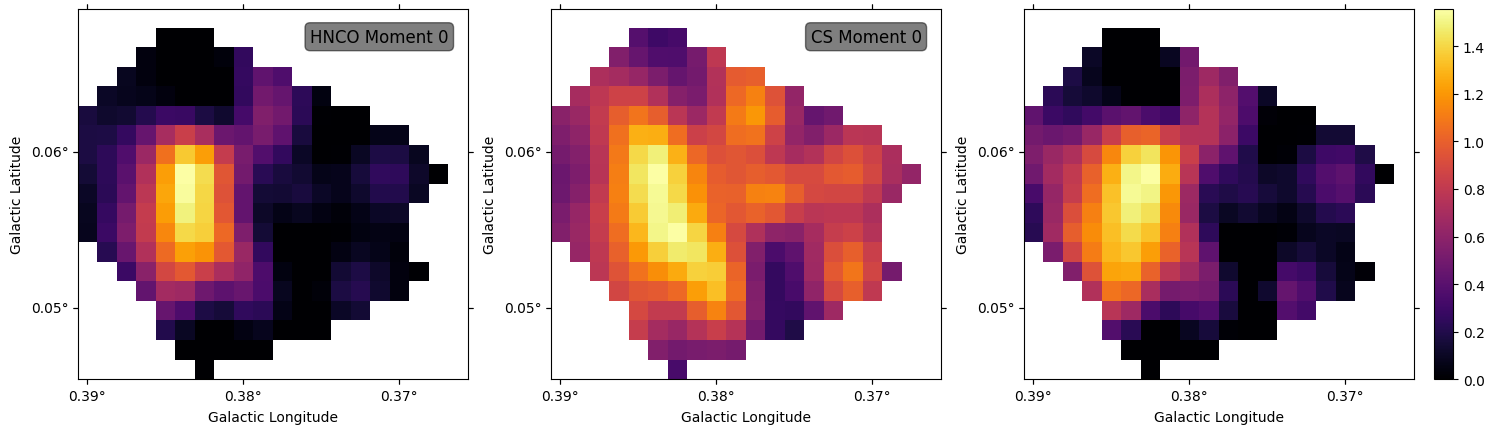

In [24]:
cube_c2_HNCO_range2 = cube_c2_HNCO.spectral_slab(-5*u.km/u.s, 3*u.km/u.s)
cube_c2_CS_range2 = cube_c2_CS.spectral_slab(-5*u.km/u.s, 3*u.km/u.s)
mom0_c2_HNCO_range2 = cube_c2_HNCO_range2.with_mask(mask_c2_HNCO).moment(order=0)
mom0_c2_CS_range2 = cube_c2_CS_range2.with_mask(mask_c2_CS).moment(order=0)
ratio_c2_HNCO_CS_range2 = mom0_c2_HNCO_range2 / mom0_c2_CS_range2

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_c2_HNCO_range2.wcs)
ax1.imshow(mom0_c2_HNCO_range2.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.95, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_c2_CS_range2.wcs)
ax2.imshow(mom0_c2_CS_range2.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.95, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_c2_HNCO_CS_range2.wcs)
im = ax3.imshow(ratio_c2_HNCO_CS_range2.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

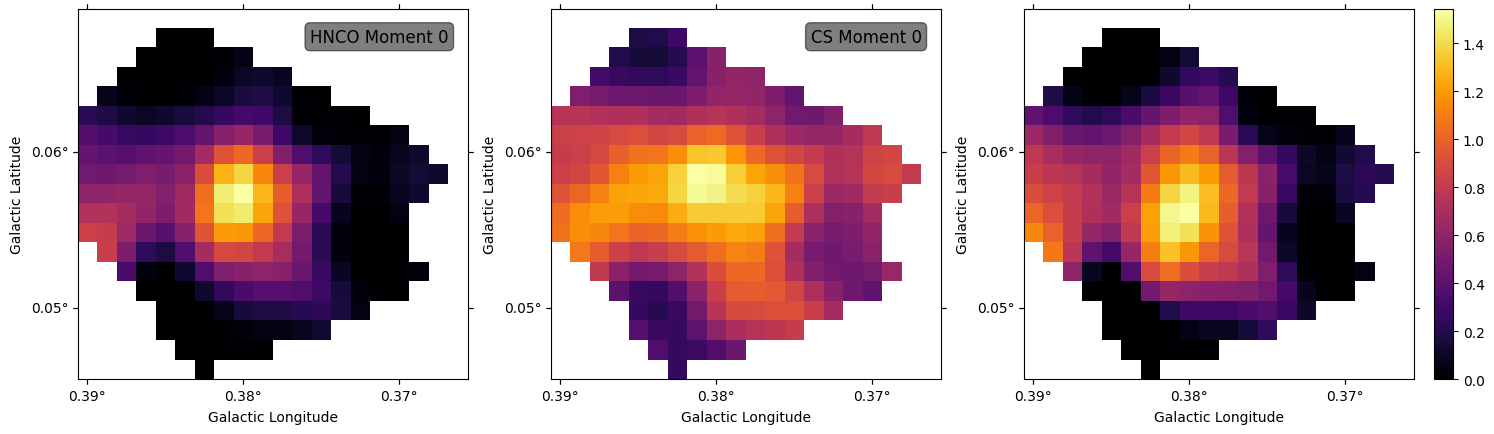

In [25]:
cube_c2_HNCO_range3 = cube_c2_HNCO.spectral_slab(3*u.km/u.s, 20*u.km/u.s)
cube_c2_CS_range3 = cube_c2_CS.spectral_slab(3*u.km/u.s, 20*u.km/u.s)
mom0_c2_HNCO_range3 = cube_c2_HNCO_range3.with_mask(mask_c2_HNCO).moment(order=0)
mom0_c2_CS_range3 = cube_c2_CS_range3.with_mask(mask_c2_CS).moment(order=0)
ratio_c2_HNCO_CS_range3 = mom0_c2_HNCO_range3 / mom0_c2_CS_range3

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_c2_HNCO_range3.wcs)
ax1.imshow(mom0_c2_HNCO_range3.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.95, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_c2_CS_range3.wcs)
ax2.imshow(mom0_c2_CS_range3.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.95, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_c2_HNCO_CS_range3.wcs)
im = ax3.imshow(ratio_c2_HNCO_CS_range3.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

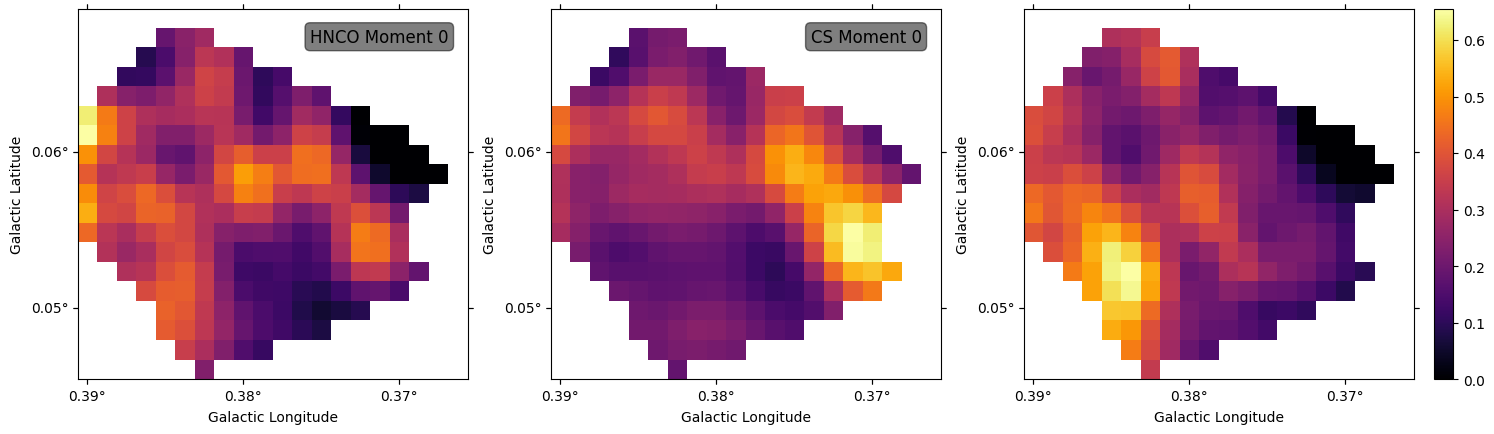

In [26]:
cube_c2_HNCO_range4 = cube_c2_HNCO.spectral_slab(20*u.km/u.s, 30*u.km/u.s)
cube_c2_CS_range4 = cube_c2_CS.spectral_slab(20*u.km/u.s, 30*u.km/u.s)
mom0_c2_HNCO_range4 = cube_c2_HNCO_range4.with_mask(mask_c2_HNCO).moment(order=0)
mom0_c2_CS_range4 = cube_c2_CS_range4.with_mask(mask_c2_CS).moment(order=0)
ratio_c2_HNCO_CS_range4 = mom0_c2_HNCO_range4 / mom0_c2_CS_range4

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_c2_HNCO_range4.wcs)
ax1.imshow(mom0_c2_HNCO_range4.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.95, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_c2_CS_range4.wcs)
ax2.imshow(mom0_c2_CS_range4.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.95, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_c2_HNCO_CS_range4.wcs)
im = ax3.imshow(ratio_c2_HNCO_CS_range4.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

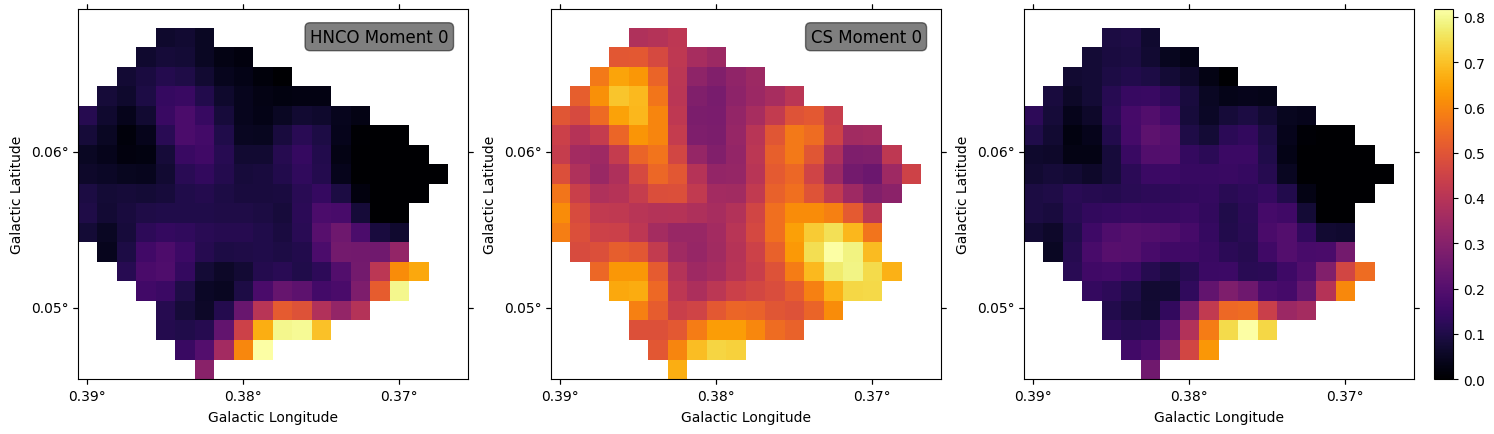

In [27]:
cube_c2_HNCO_range5 = cube_c2_HNCO.spectral_slab(30*u.km/u.s, 50*u.km/u.s)
cube_c2_CS_range5 = cube_c2_CS.spectral_slab(30*u.km/u.s, 50*u.km/u.s)
mom0_c2_HNCO_range5 = cube_c2_HNCO_range5.with_mask(mask_c2_HNCO).moment(order=0)
mom0_c2_CS_range5 = cube_c2_CS_range5.with_mask(mask_c2_CS).moment(order=0)
ratio_c2_HNCO_CS_range5 = mom0_c2_HNCO_range5 / mom0_c2_CS_range5

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_c2_HNCO_range5.wcs)
ax1.imshow(mom0_c2_HNCO_range5.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.95, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_c2_CS_range5.wcs)
ax2.imshow(mom0_c2_CS_range5.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.95, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_c2_HNCO_CS_range5.wcs)
im = ax3.imshow(ratio_c2_HNCO_CS_range5.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

### Cloud D

In [28]:
# Cloud D
cube_d_HNCO = cube_HNCO.subcube_from_regions(reg_d, minimize=False)
spec_d_HNCO = cube_d_HNCO.mean(axis=(1, 2))
cube_d_CS = cube_CS.subcube_from_regions(reg_d, minimize=False)
spec_d_CS = cube_d_CS.mean(axis=(1, 2))
#cube_d_SiO = cube_SiO.subcube_from_regions(reg_d, minimize=False)
#spec_d_SiO = cube_d_SiO.mean(axis=(1, 2))

/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: Mean of empty slice
  out = function(self._get_filled_data(fill=fill,


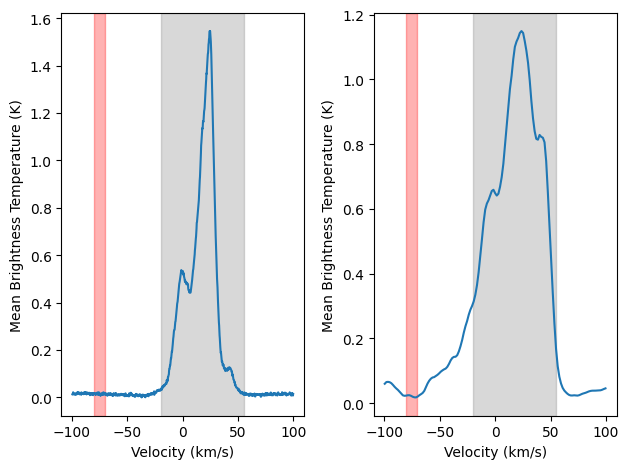

In [29]:
ax1 = plt.subplot(121)
ax1.plot(spec_d_HNCO.spectral_axis, spec_d_HNCO.value, label='HNCO')
ax1.set_xlabel('Velocity (km/s)')
ax1.set_ylabel('Mean Brightness Temperature (K)')

ax2 = plt.subplot(122)
ax2.plot(spec_d_CS.spectral_axis, spec_d_CS.value, label='CS')
ax2.set_xlabel('Velocity (km/s)')
ax2.set_ylabel('Mean Brightness Temperature (K)')

for ax in [ax1, ax2]:
    #ax.axvspan(10, 35, color='gray', alpha=0.3)
    ax.axvspan(-20, 55, color='gray', alpha=0.3)
    #ax.axvspan(35, 55, color='red', alpha=0.3)
    #ax.axvspan(-20, 8, color='blue', alpha=0.3)
    ax.axvspan(-80, -70, color='red', alpha=0.3)

plt.tight_layout()

In [30]:
mask_d_HNCO = noise_mask(cube_d_HNCO, -80*u.km/u.s, -70*u.km/u.s, 5)
mask_d_CS = noise_mask(cube_d_CS, -80*u.km/u.s, -70*u.km/u.s, 5)

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,


In [31]:
cube_d_HNCO_range = cube_d_HNCO.spectral_slab(10*u.km/u.s, 35*u.km/u.s)
cube_d_CS_range = cube_d_CS.spectral_slab(10*u.km/u.s, 35*u.km/u.s)

mom0_d_HNCO = cube_d_HNCO_range.with_mask(mask_d_HNCO).moment(order=0)
mom0_d_CS = cube_d_CS_range.with_mask(mask_d_CS).moment(order=0)

ratio_d_HNCO_CS = mom0_d_HNCO / mom0_d_CS

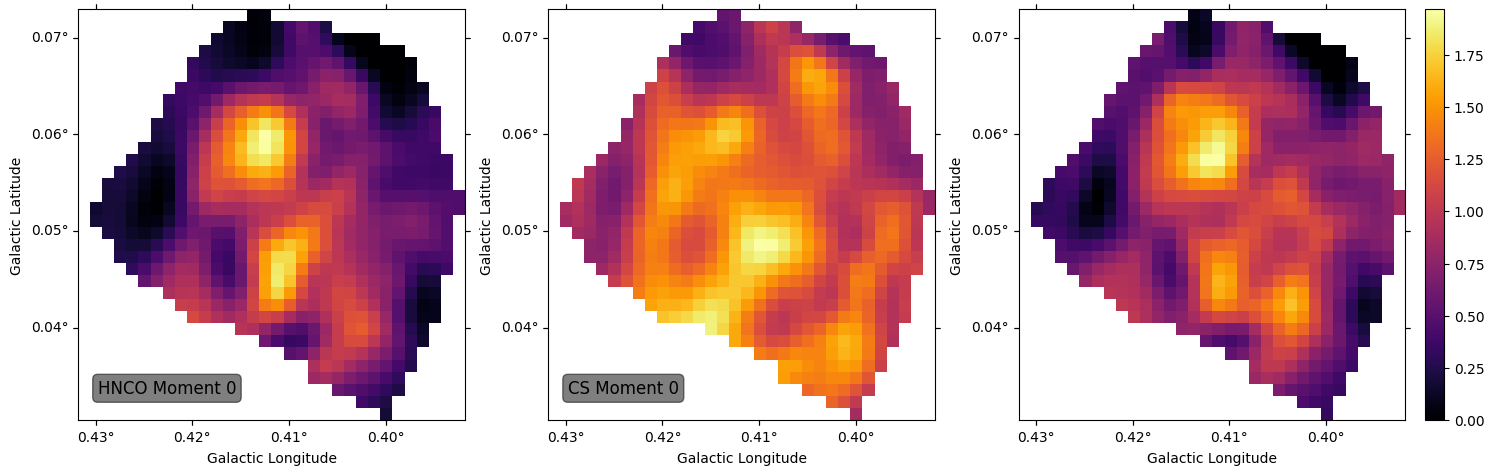

In [32]:
fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_d_HNCO.wcs)
ax1.imshow(mom0_d_HNCO.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.05, 0.1, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_d_CS.wcs)
ax2.imshow(mom0_d_CS.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.05, 0.1, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_d_HNCO_CS.wcs)
im = ax3.imshow(ratio_d_HNCO_CS.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

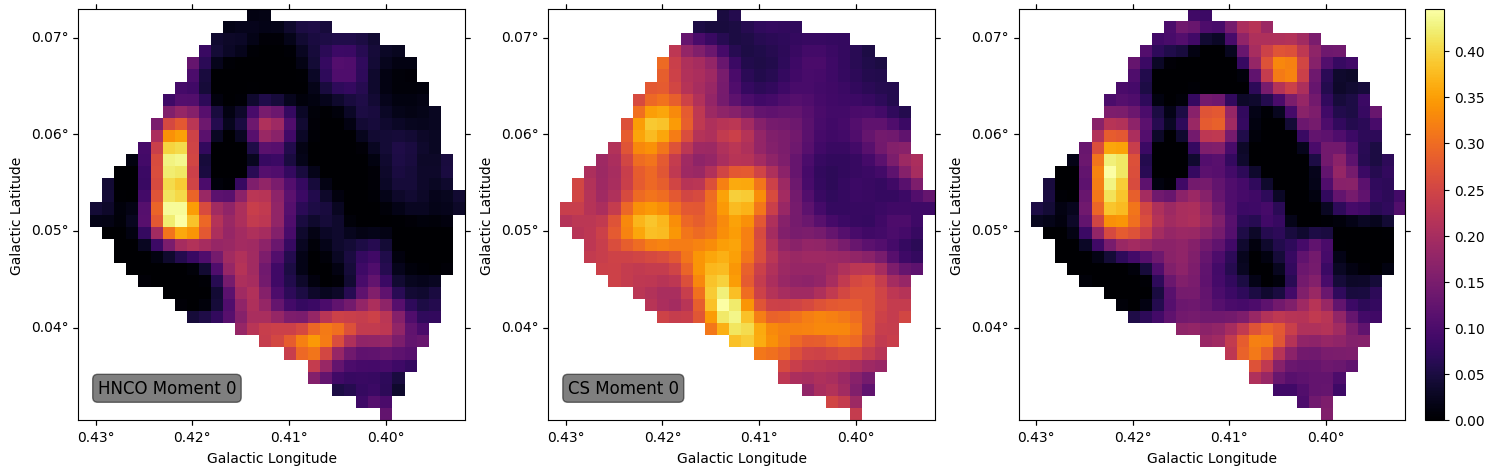

In [33]:
cube_d_HNCO_range1 = cube_d_HNCO.spectral_slab(35*u.km/u.s, 55*u.km/u.s)
cube_d_CS_range1 = cube_d_CS.spectral_slab(35*u.km/u.s, 55*u.km/u.s)
mom0_d_HNCO_range1 = cube_d_HNCO_range1.with_mask(mask_d_HNCO).moment(order=0)
mom0_d_CS_range1 = cube_d_CS_range1.with_mask(mask_d_CS).moment(order=0)
ratio_d_HNCO_CS_range1 = mom0_d_HNCO_range1 / mom0_d_CS_range1

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_d_HNCO_range1.wcs)
ax1.imshow(mom0_d_HNCO_range1.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.05, 0.1, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_d_CS_range1.wcs)
ax2.imshow(mom0_d_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.05, 0.1, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_d_HNCO_CS_range1.wcs)
im = ax3.imshow(ratio_d_HNCO_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

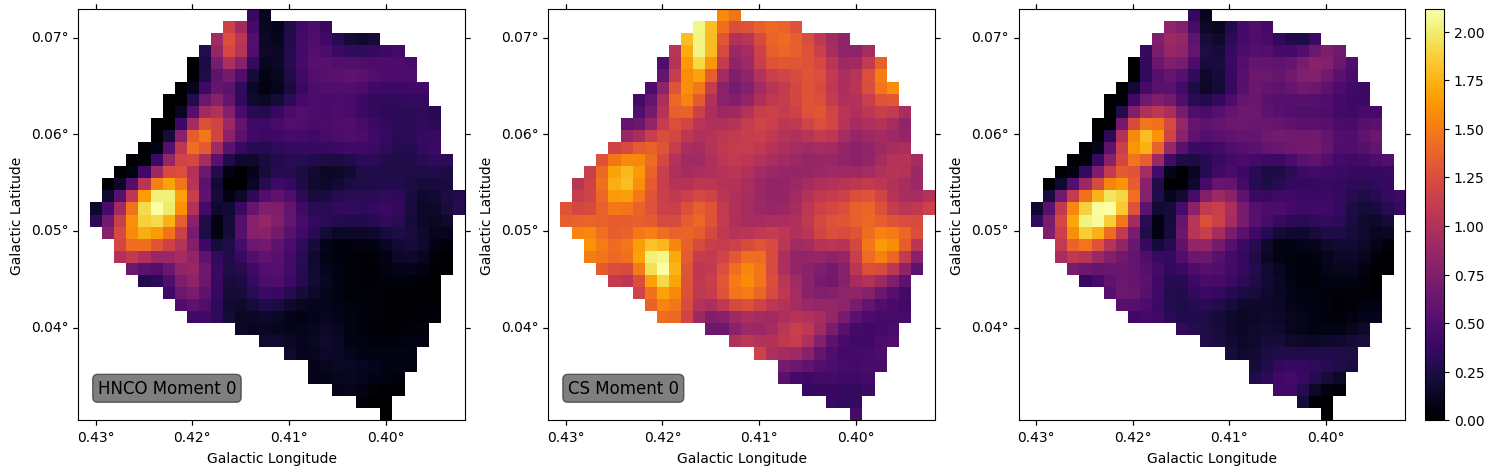

In [34]:
cube_d_HNCO_range2 = cube_d_HNCO.spectral_slab(-20*u.km/u.s, 8*u.km/u.s)
cube_d_CS_range2 = cube_d_CS.spectral_slab(-20*u.km/u.s, 8*u.km/u.s)
mom0_d_HNCO_range2 = cube_d_HNCO_range2.with_mask(mask_d_HNCO).moment(order=0)
mom0_d_CS_range2 = cube_d_CS_range2.with_mask(mask_d_CS).moment(order=0)
ratio_d_HNCO_CS_range2 = mom0_d_HNCO_range2 / mom0_d_CS_range2

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_d_HNCO_range2.wcs)
ax1.imshow(mom0_d_HNCO_range2.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.05, 0.1, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_d_CS_range2.wcs)
ax2.imshow(mom0_d_CS_range2.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.05, 0.1, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_d_HNCO_CS_range2.wcs)
im = ax3.imshow(ratio_d_HNCO_CS_range2.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

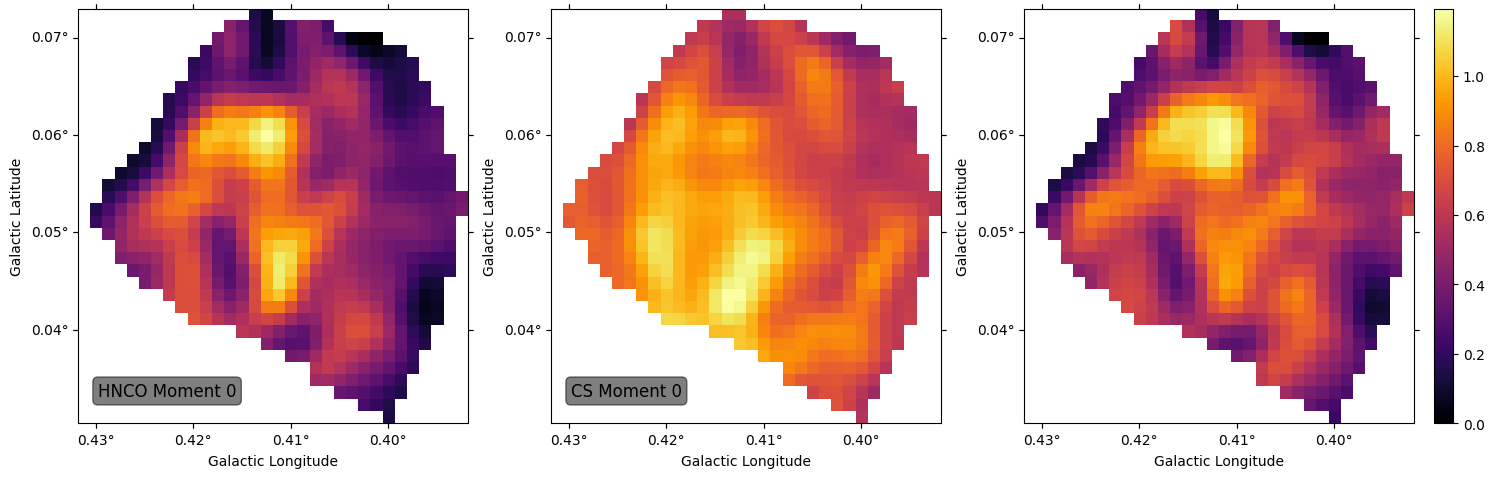

In [35]:
cube_d_HNCO_range3 = cube_d_HNCO.spectral_slab(-20*u.km/u.s, 55*u.km/u.s)
cube_d_CS_range3 = cube_d_CS.spectral_slab(-20*u.km/u.s, 55*u.km/u.s)
mom0_d_HNCO_range3 = cube_d_HNCO_range3.with_mask(mask_d_HNCO).moment(order=0)
mom0_d_CS_range3 = cube_d_CS_range3.with_mask(mask_d_CS).moment(order=0)
ratio_d_HNCO_CS_range3 = mom0_d_HNCO_range3 / mom0_d_CS_range3

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_d_HNCO_range3.wcs)
ax1.imshow(mom0_d_HNCO_range3.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.05, 0.1, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_d_CS_range3.wcs)
ax2.imshow(mom0_d_CS_range3.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.05, 0.1, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_d_HNCO_CS_range3.wcs)
im = ax3.imshow(ratio_d_HNCO_CS_range3.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

### Cloud B

In [36]:
# Cloud B
cube_b_HNCO = cube_HNCO.subcube_from_regions(reg_b, minimize=False)
spec_b_HNCO = cube_b_HNCO.mean(axis=(1, 2))
cube_b_CS = cube_CS.subcube_from_regions(reg_b, minimize=False)
spec_b_CS = cube_b_CS.mean(axis=(1, 2))
#cube_b_SiO = cube_SiO.subcube_from_regions(reg_b, minimize=False)
#spec_b_SiO = cube_b_SiO.mean(axis=(1, 2))

/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: Mean of empty slice
  out = function(self._get_filled_data(fill=fill,


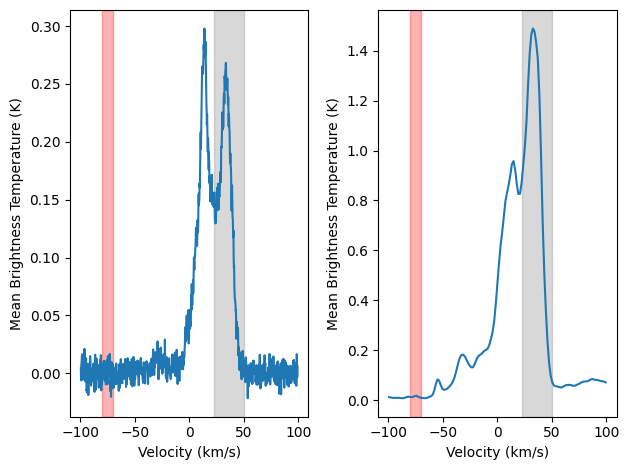

In [37]:
ax1 = plt.subplot(121)
ax1.plot(spec_b_HNCO.spectral_axis, spec_b_HNCO.value, label='HNCO')
ax1.set_xlabel('Velocity (km/s)')
ax1.set_ylabel('Mean Brightness Temperature (K)')

ax2 = plt.subplot(122)
ax2.plot(spec_b_CS.spectral_axis, spec_b_CS.value, label='CS')
ax2.set_xlabel('Velocity (km/s)')
ax2.set_ylabel('Mean Brightness Temperature (K)')

for ax in [ax1, ax2]:
    ax.axvspan(23, 50, color='gray', alpha=0.3)
    #ax.axvspan(0, 23, color='gray', alpha=0.3)
    ax.axvspan(-80, -70, color='red', alpha=0.3)

plt.tight_layout()

In [38]:
mask_b_HNCO = noise_mask(cube_b_HNCO, -80*u.km/u.s, -70*u.km/u.s, 5)
mask_b_CS = noise_mask(cube_b_CS, -80*u.km/u.s, -70*u.km/u.s, 5)

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,


In [39]:
cube_b_HNCO_range = cube_b_HNCO.spectral_slab(23*u.km/u.s, 50*u.km/u.s)
cube_b_CS_range = cube_b_CS.spectral_slab(23*u.km/u.s, 50*u.km/u.s)
#cube_b_HNCO_range = cube_b_HNCO.spectral_slab(0*u.km/u.s, 50*u.km/u.s)
#cube_b_CS_range = cube_b_CS.spectral_slab(0*u.km/u.s, 50*u.km/u.s)

mom0_b_HNCO = cube_b_HNCO_range.moment(order=0)
mom0_b_CS = cube_b_CS_range.moment(order=0)

ratio_b_HNCO_CS = mom0_b_HNCO / mom0_b_CS

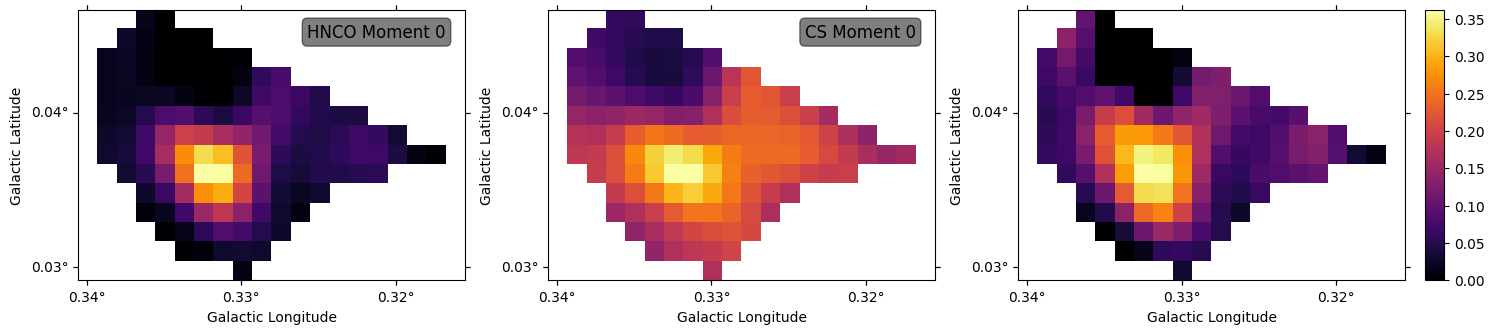

In [40]:
fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_b_HNCO.wcs)
ax1.imshow(mom0_b_HNCO.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.95, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_b_CS.wcs)
ax2.imshow(mom0_b_CS.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.95, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_b_HNCO_CS.wcs)
im = ax3.imshow(ratio_b_HNCO_CS.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

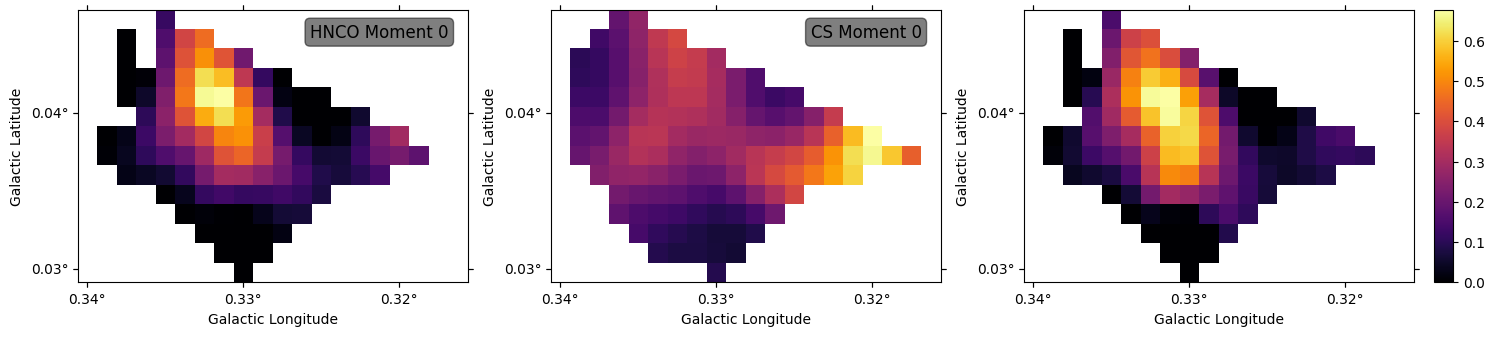

In [41]:
cube_b_HNCO_range2 = cube_b_HNCO.spectral_slab(0*u.km/u.s, 23*u.km/u.s)
cube_b_CS_range2 = cube_b_CS.spectral_slab(0*u.km/u.s, 23*u.km/u.s)
#cube_b_HNCO_range = cube_b_HNCO.spectral_slab(0*u.km/u.s, 50*u.km/u.s)
#cube_b_CS_range = cube_b_CS.spectral_slab(0*u.km/u.s, 50*u.km/u.s)

mom0_b_HNCO_range2 = cube_b_HNCO_range2.with_mask(mask_b_HNCO).moment(order=0)
mom0_b_CS_range2 = cube_b_CS_range2.with_mask(mask_b_CS).moment(order=0)

ratio_b_HNCO_CS_range2 = mom0_b_HNCO_range2 / mom0_b_CS_range2

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_b_HNCO_range2.wcs)
ax1.imshow(mom0_b_HNCO_range2.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.95, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_b_CS_range2.wcs)
ax2.imshow(mom0_b_CS_range2.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.95, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_b_HNCO_CS_range2.wcs)
im = ax3.imshow(ratio_b_HNCO_CS_range2.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

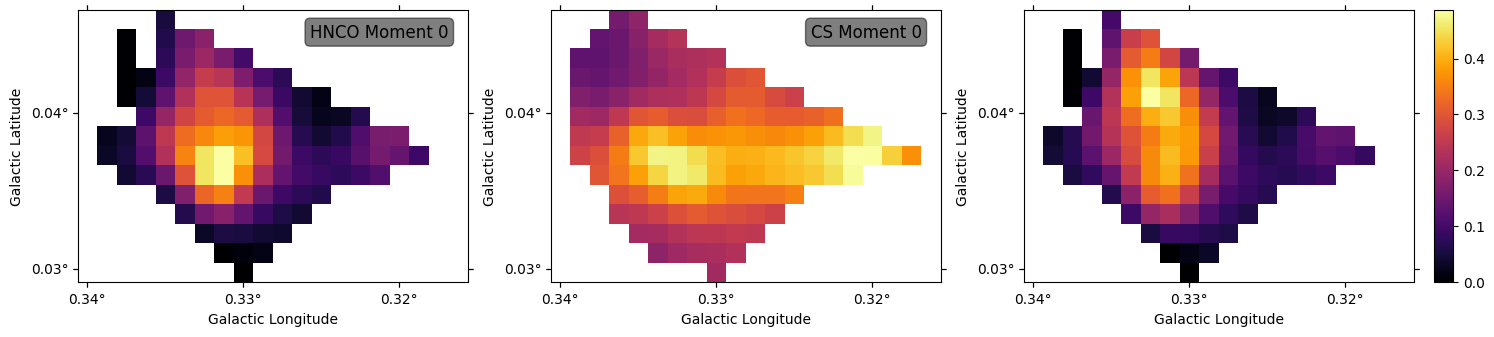

In [42]:
cube_b_HNCO_range3 = cube_b_HNCO.spectral_slab(0*u.km/u.s, 50*u.km/u.s)
cube_b_CS_range3 = cube_b_CS.spectral_slab(0*u.km/u.s, 50*u.km/u.s)
#cube_b_HNCO_range = cube_b_HNCO.spectral_slab(0*u.km/u.s, 50*u.km/u.s)
#cube_b_CS_range = cube_b_CS.spectral_slab(0*u.km/u.s, 50*u.km/u.s)

mom0_b_HNCO_range3 = cube_b_HNCO_range3.with_mask(mask_b_HNCO).moment(order=0)
mom0_b_CS_range3 = cube_b_CS_range3.with_mask(mask_b_CS).moment(order=0)

ratio_b_HNCO_CS_range3 = mom0_b_HNCO_range3 / mom0_b_CS_range3

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_b_HNCO_range3.wcs)
ax1.imshow(mom0_b_HNCO_range3.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.95, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_b_CS_range3.wcs)
ax2.imshow(mom0_b_CS_range3.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.95, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_b_HNCO_CS_range3.wcs)
im = ax3.imshow(ratio_b_HNCO_CS_range3.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

### Summary

In [43]:
#spectra_cloudc_HNCO = [spec_f_HNCO, spec_b_HNCO, spec_c1_HNCO, spec_c2_HNCO, spec_d_HNCO, spec_fil_r_HNCO, spec_left_cd_HNCO, spec_c_n_HNCO, spec_c_s_HNCO]
#spectra_cloudc_CS = [spec_f_CS, spec_b_CS, spec_c1_CS, spec_c2_CS, spec_d_CS, spec_fil_r_CS, spec_left_cd_CS, spec_c_n_CS, spec_c_s_CS]
#spectra_cloudc_SiO = [spec_f_SiO, spec_b_SiO, spec_c1_SiO, spec_c2_SiO, spec_d_SiO, spec_fil_r_SiO, spec_left_cd_SiO, spec_c_n_SiO, spec_c_s_SiO]

spectra_cloudc_HNCO = [spec_f_HNCO, spec_b_HNCO, spec_c1_HNCO, spec_c2_HNCO, spec_d_HNCO]
spectra_cloudc_CS = [spec_f_CS, spec_b_CS, spec_c1_CS, spec_c2_CS, spec_d_CS]
#spectra_cloudc_SiO = [spec_f_SiO, spec_b_SiO, spec_c1_SiO, spec_c2_SiO, spec_d_SiO]

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

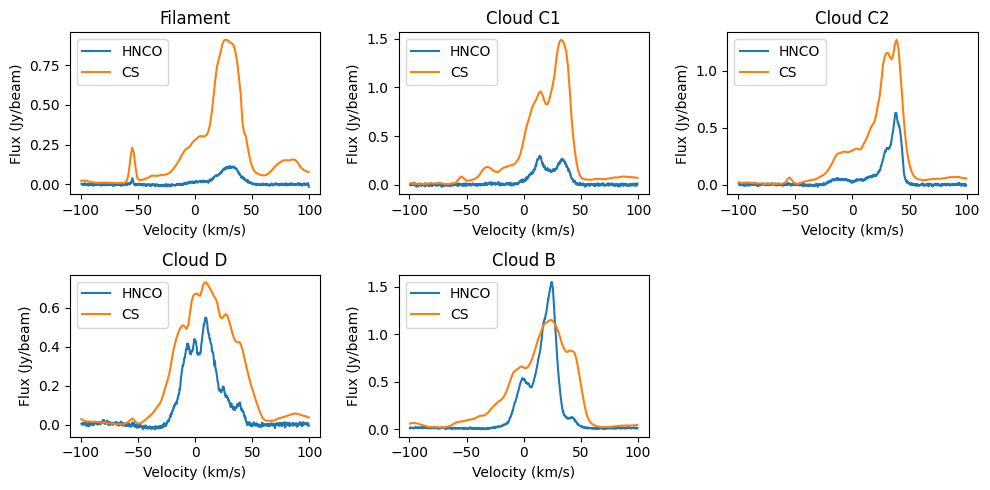

In [44]:
#fig, axes = plt.subplots(3, 3, figsize=(15, 15))
#for i in range(9):
fig, axes = plt.subplots(2, 3, figsize=(10, 5))
for i in range(5):
    ax = axes.flatten()[i]
    spec_HNCO = spectra_cloudc_HNCO[i]
    spec_CS = spectra_cloudc_CS[i]
    #spec_SiO = spectra_cloudc_SiO[i]
    ax.plot(spec_HNCO.spectral_axis.to(u.km/u.s), spec_HNCO.value, label='HNCO')
    ax.plot(spec_CS.spectral_axis.to(u.km/u.s), spec_CS.value, label='CS')
    #ax.plot(spec_SiO.spectral_axis.to(u.km/u.s), spec_SiO.value, label='SiO')
    ax.set_xlabel('Velocity (km/s)')
    ax.set_ylabel('Flux (Jy/beam)')
    ax.set_title(labels_cloudc[i])
    ax.legend()
plt.tight_layout()

axes.flatten()[-1].axis('off')

In [45]:
#fig, axes = plt.subplots(3,3, figsize=(15,15))
#
#for i in range(len(regions_cloudc)):
#    cutout = cube_HNCO.subcube_from_regions([regions_cloudc[i][0]], minimize=False)
#    cutout.allow_huge_operations = True
#    spec = cutout.mean(axis=(1,2))
#    #print(cutout.shape)
#    ax = axes.flatten()[i]
#    ax.plot(cutout.spectral_axis, spec.value)
#    ax.set_title(labels_cloudc[i])
#    ax.set_xlabel('Velocity (km/s)')
#    ax.set_ylabel('Flux (Jy/beam)')

## Brick

### Brick North

In [46]:
# reg_brick_north 
cube_brick_north_HNCO = cube_HNCO.subcube_from_regions(reg_brick_north, minimize=False)
spec_brick_north_HNCO = cube_brick_north_HNCO.mean(axis=(1, 2))
cube_brick_north_CS = cube_CS.subcube_from_regions(reg_brick_north, minimize=False)
spec_brick_north_CS = cube_brick_north_CS.mean(axis=(1, 2))
#cube_brick_north_SiO = cube_SiO.subcube_from_regions(reg_brick_north, minimize=False)
#spec_brick_north_SiO = cube_brick_north_SiO.mean(axis=(1, 2))



/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: Mean of empty slice
  out = function(self._get_filled_data(fill=fill,


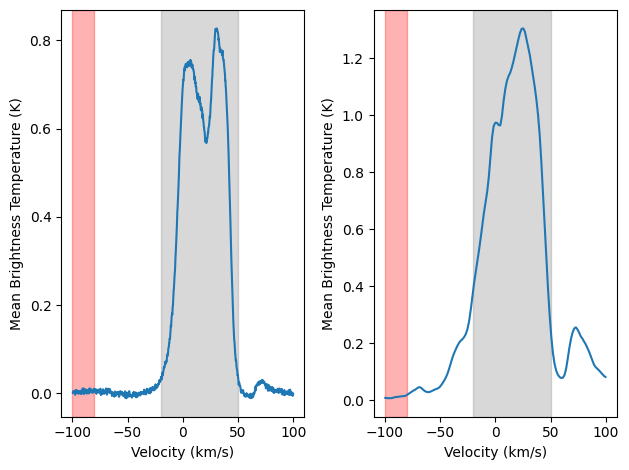

In [47]:
ax1 = plt.subplot(121)
ax1.plot(spec_brick_north_HNCO.spectral_axis, spec_brick_north_HNCO.value, label='HNCO')
ax1.set_xlabel('Velocity (km/s)')
ax1.set_ylabel('Mean Brightness Temperature (K)')

ax2 = plt.subplot(122)
ax2.plot(spec_brick_north_CS.spectral_axis, spec_brick_north_CS.value, label='CS')
ax2.set_xlabel('Velocity (km/s)')
ax2.set_ylabel('Mean Brightness Temperature (K)')

for ax in [ax1, ax2]:
    ax.axvspan(-20, 50, color='gray', alpha=0.3)
    ax.axvspan(-100, -80, color='red', alpha=0.3)

plt.tight_layout()

In [48]:
mask_brick_north_HNCO = noise_mask(cube_brick_north_HNCO, -100*u.km/u.s, -80*u.km/u.s, 5)
mask_brick_north_CS = noise_mask(cube_brick_north_CS, -100*u.km/u.s, -80*u.km/u.s, 5)

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,


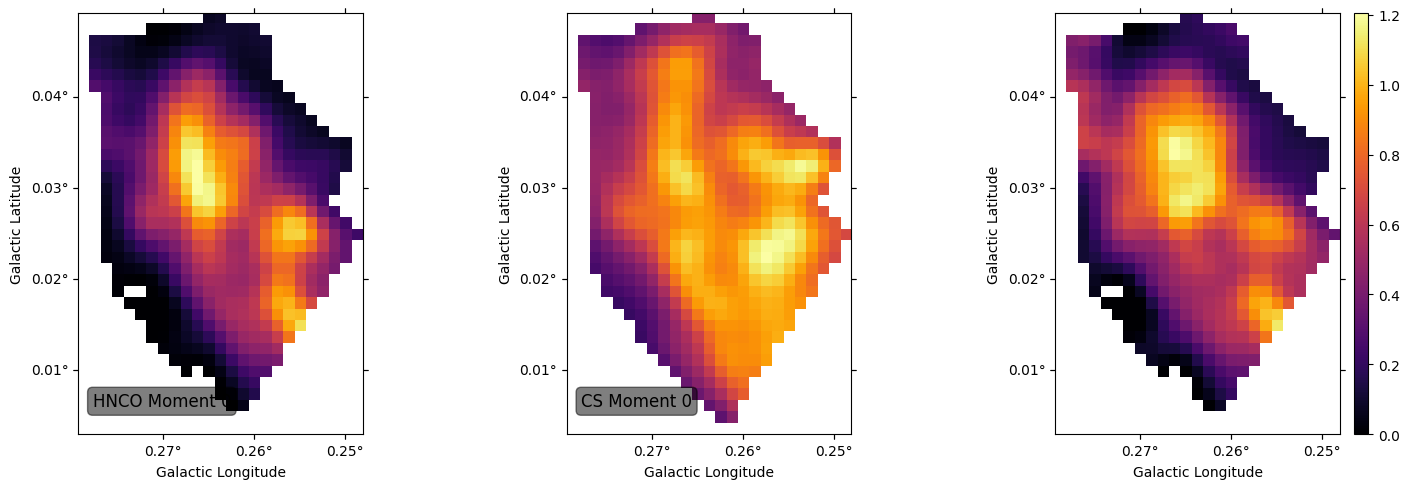

In [49]:
cube_brick_north_HNCO_range2 = cube_brick_north_HNCO.spectral_slab(-20*u.km/u.s, 50*u.km/u.s)
cube_brick_north_CS_range2 = cube_brick_north_CS.spectral_slab(-20*u.km/u.s, 50*u.km/u.s)

mom0_brick_north_HNCO_range2 = cube_brick_north_HNCO_range2.with_mask(mask_brick_north_HNCO).moment(order=0)
mom0_brick_north_CS_range2 = cube_brick_north_CS_range2.with_mask(mask_brick_north_CS).moment(order=0)

ratio_brick_north_HNCO_CS_range2 = mom0_brick_north_HNCO_range2 / mom0_brick_north_CS_range2

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_brick_north_HNCO_range2.wcs)
ax1.imshow(mom0_brick_north_HNCO_range2.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.05, 0.1, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_brick_north_CS_range2.wcs)
ax2.imshow(mom0_brick_north_CS_range2.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.05, 0.1, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_brick_north_HNCO_CS_range2.wcs)
im = ax3.imshow(ratio_brick_north_HNCO_CS_range2.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

### Brick South

In [50]:
#reg_brick_south 
cube_brick_south_HNCO = cube_HNCO.subcube_from_regions(reg_brick_south, minimize=False)
spec_brick_south_HNCO = cube_brick_south_HNCO.mean(axis=(1, 2))
cube_brick_south_CS = cube_CS.subcube_from_regions(reg_brick_south, minimize=False)
spec_brick_south_CS = cube_brick_south_CS.mean(axis=(1, 2))
#cube_brick_south_SiO = cube_SiO.subcube_from_regions(reg_brick_south, minimize=False)
#spec_brick_south_SiO = cube_brick_south_SiO.mean(axis=(1, 2))



/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: Mean of empty slice
  out = function(self._get_filled_data(fill=fill,


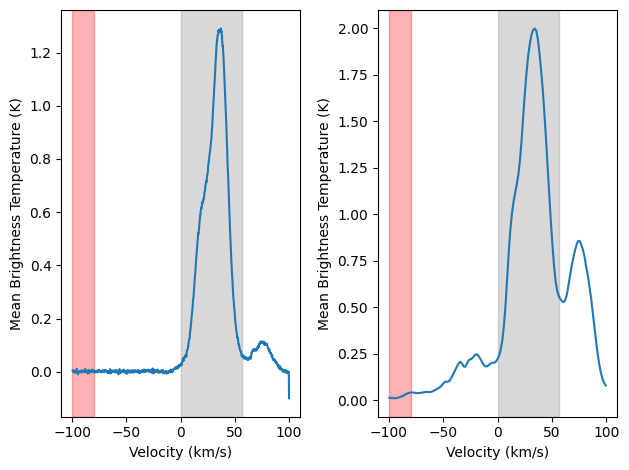

In [51]:
ax1 = plt.subplot(121)
ax1.plot(spec_brick_south_HNCO.spectral_axis, spec_brick_south_HNCO.value, label='HNCO')
ax1.set_xlabel('Velocity (km/s)')
ax1.set_ylabel('Mean Brightness Temperature (K)')

ax2 = plt.subplot(122)
ax2.plot(spec_brick_south_CS.spectral_axis, spec_brick_south_CS.value, label='CS')
ax2.set_xlabel('Velocity (km/s)')
ax2.set_ylabel('Mean Brightness Temperature (K)')

for ax in [ax1, ax2]:
    ax.axvspan(0, 57, color='gray', alpha=0.3)
    ax.axvspan(-100, -80, color='red', alpha=0.3)

plt.tight_layout()

In [52]:
mask_brick_south_HNCO = noise_mask(cube_brick_south_HNCO, -100*u.km/u.s, -80*u.km/u.s, 5)
mask_brick_south_CS = noise_mask(cube_brick_south_CS, -100*u.km/u.s, -80*u.km/u.s, 5)

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,


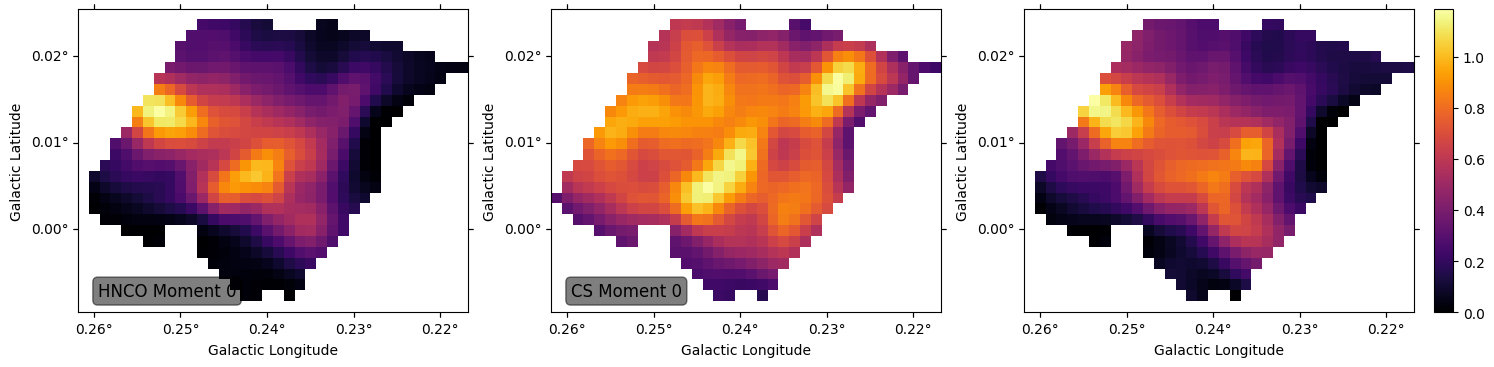

In [53]:
cube_brick_south_HNCO_range2 = cube_brick_south_HNCO.spectral_slab(0*u.km/u.s, 57*u.km/u.s)
cube_brick_south_CS_range2 = cube_brick_south_CS.spectral_slab(0*u.km/u.s, 57*u.km/u.s)

mom0_brick_south_HNCO_range2 = cube_brick_south_HNCO_range2.with_mask(mask_brick_south_HNCO).moment(order=0)
mom0_brick_south_CS_range2 = cube_brick_south_CS_range2.with_mask(mask_brick_south_CS).moment(order=0)

ratio_brick_south_HNCO_CS_range2 = mom0_brick_south_HNCO_range2 / mom0_brick_south_CS_range2

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_brick_south_HNCO_range2.wcs)
ax1.imshow(mom0_brick_south_HNCO_range2.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.05, 0.1, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_brick_south_CS_range2.wcs)
ax2.imshow(mom0_brick_south_CS_range2.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.05, 0.1, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_brick_south_HNCO_CS_range2.wcs)
im = ax3.imshow(ratio_brick_south_HNCO_CS_range2.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

### Brick Head

In [54]:
#reg_brick_head 
cube_brick_head_HNCO = cube_HNCO.subcube_from_regions(reg_brick_head, minimize=False)
spec_brick_head_HNCO = cube_brick_head_HNCO.mean(axis=(1, 2))
cube_brick_head_CS = cube_CS.subcube_from_regions(reg_brick_head, minimize=False)
spec_brick_head_CS = cube_brick_head_CS.mean(axis=(1, 2))
#cube_brick_head_SiO = cube_SiO.subcube_from_regions(reg_brick_head, minimize=False)
#spec_brick_head_SiO = cube_brick_head_SiO.mean(axis=(1, 2))



/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: Mean of empty slice
  out = function(self._get_filled_data(fill=fill,


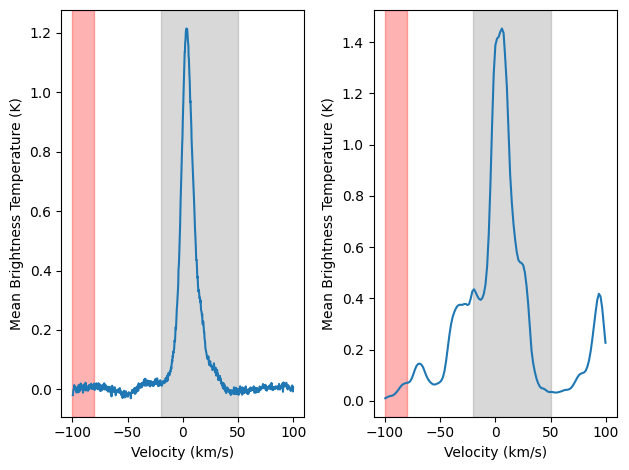

In [55]:
ax1 = plt.subplot(121)
ax1.plot(spec_brick_head_HNCO.spectral_axis, spec_brick_head_HNCO.value, label='HNCO')
ax1.set_xlabel('Velocity (km/s)')
ax1.set_ylabel('Mean Brightness Temperature (K)')

ax2 = plt.subplot(122)
ax2.plot(spec_brick_head_CS.spectral_axis, spec_brick_head_CS.value, label='CS')
ax2.set_xlabel('Velocity (km/s)')
ax2.set_ylabel('Mean Brightness Temperature (K)')

for ax in [ax1, ax2]:
    ax.axvspan(-20, 50, color='gray', alpha=0.3)
    ax.axvspan(-100, -80, color='red', alpha=0.3)

plt.tight_layout()

In [56]:
mask_brick_head_HNCO = noise_mask(cube_brick_head_HNCO, -100*u.km/u.s, -80*u.km/u.s, 5)
mask_brick_head_CS = noise_mask(cube_brick_head_CS, -100*u.km/u.s, -80*u.km/u.s, 5)

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,


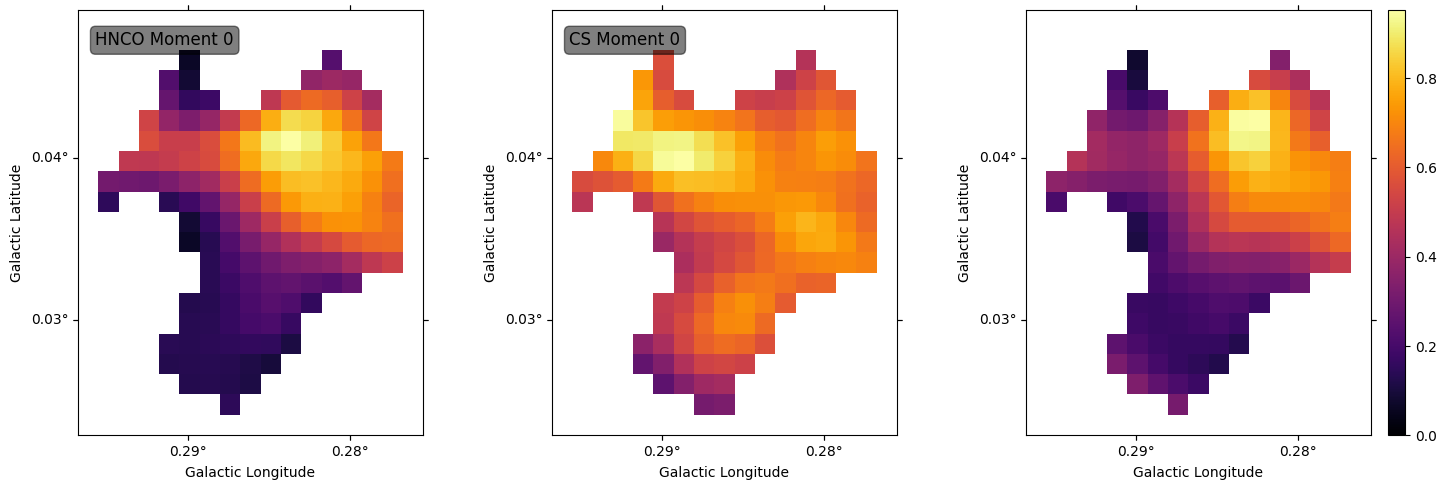

In [57]:
cube_brick_head_HNCO_range2 = cube_brick_head_HNCO.spectral_slab(-20*u.km/u.s, 50*u.km/u.s)
cube_brick_head_CS_range2 = cube_brick_head_CS.spectral_slab(-20*u.km/u.s, 50*u.km/u.s)

mom0_brick_head_HNCO_range2 = cube_brick_head_HNCO_range2.with_mask(mask_brick_head_HNCO).moment(order=0)
mom0_brick_head_CS_range2 = cube_brick_head_CS_range2.with_mask(mask_brick_head_CS).moment(order=0)

ratio_brick_head_HNCO_CS_range2 = mom0_brick_head_HNCO_range2 / mom0_brick_head_CS_range2

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_brick_head_HNCO_range2.wcs)
ax1.imshow(mom0_brick_head_HNCO_range2.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.05, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_brick_head_CS_range2.wcs)
ax2.imshow(mom0_brick_head_CS_range2.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.05, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_brick_head_HNCO_CS_range2.wcs)
im = ax3.imshow(ratio_brick_head_HNCO_CS_range2.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

### Brick South Fluff

In [58]:
#reg_brick_sfluff 
cube_brick_sfluff_HNCO = cube_HNCO.subcube_from_regions(reg_brick_sfluff, minimize=False)
spec_brick_sfluff_HNCO = cube_brick_sfluff_HNCO.mean(axis=(1, 2))
cube_brick_sfluff_CS = cube_CS.subcube_from_regions(reg_brick_sfluff, minimize=False)
spec_brick_sfluff_CS = cube_brick_sfluff_CS.mean(axis=(1, 2))
#cube_brick_sfluff_SiO = cube_SiO.subcube_from_regions(reg_brick_sfluff, minimize=False)
#spec_brick_sfluff_SiO = cube_brick_sfluff_SiO.mean(axis=(1, 2))



/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: Mean of empty slice
  out = function(self._get_filled_data(fill=fill,


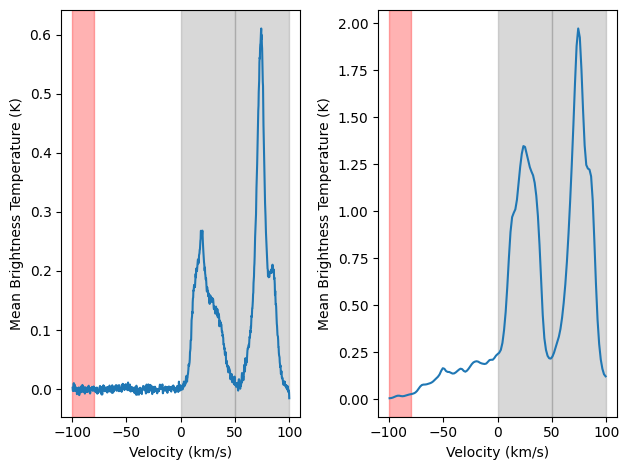

In [59]:
ax1 = plt.subplot(121)
ax1.plot(spec_brick_sfluff_HNCO.spectral_axis, spec_brick_sfluff_HNCO.value, label='HNCO')
ax1.set_xlabel('Velocity (km/s)')
ax1.set_ylabel('Mean Brightness Temperature (K)')

ax2 = plt.subplot(122)
ax2.plot(spec_brick_sfluff_CS.spectral_axis, spec_brick_sfluff_CS.value, label='CS')
ax2.set_xlabel('Velocity (km/s)')
ax2.set_ylabel('Mean Brightness Temperature (K)')

for ax in [ax1, ax2]:
    ax.axvspan(0, 50, color='gray', alpha=0.3)
    ax.axvspan(50, 100, color='gray', alpha=0.3)
    ax.axvspan(-100, -80, color='red', alpha=0.3)

plt.tight_layout()

In [60]:
mask_brick_sfluff_HNCO = noise_mask(cube_brick_sfluff_HNCO, -100*u.km/u.s, -70*u.km/u.s, 5)
mask_brick_sfluff_CS = noise_mask(cube_brick_sfluff_CS, -100*u.km/u.s, -70*u.km/u.s, 5)

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,


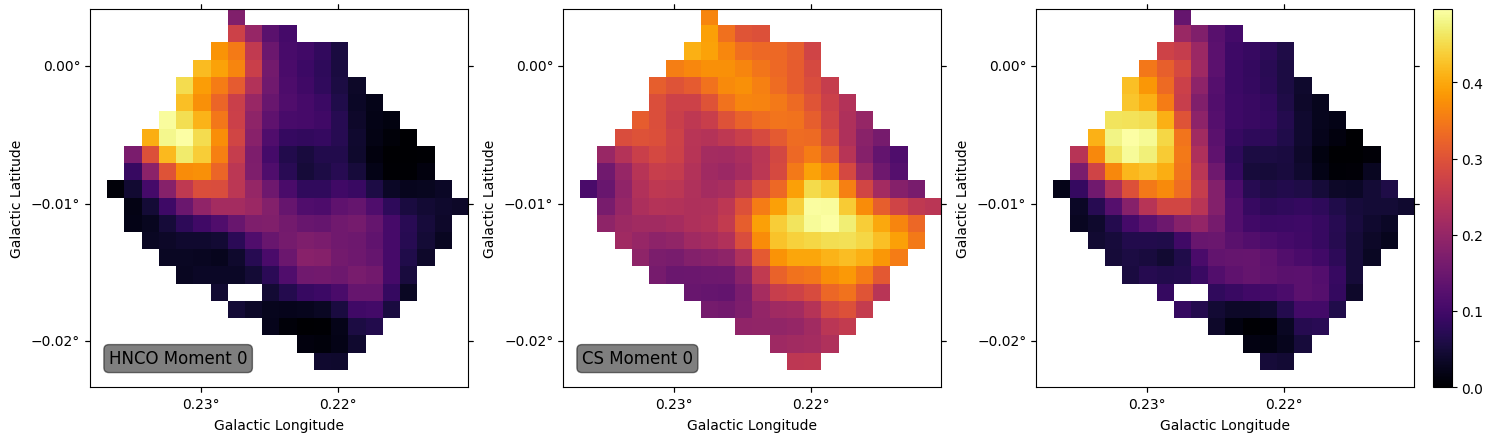

In [61]:
cube_brick_sfluff_HNCO_range1 = cube_brick_sfluff_HNCO.spectral_slab(0*u.km/u.s, 50*u.km/u.s)
cube_brick_sfluff_CS_range1 = cube_brick_sfluff_CS.spectral_slab(0*u.km/u.s, 50*u.km/u.s)

mom0_brick_sfluff_HNCO_range1 = cube_brick_sfluff_HNCO_range1.with_mask(mask_brick_sfluff_HNCO).moment(order=0)
mom0_brick_sfluff_CS_range1 = cube_brick_sfluff_CS_range1.with_mask(mask_brick_sfluff_CS).moment(order=0)

ratio_brick_sfluff_HNCO_CS_range1 = mom0_brick_sfluff_HNCO_range1 / mom0_brick_sfluff_CS_range1

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_brick_sfluff_HNCO_range1.wcs)
ax1.imshow(mom0_brick_sfluff_HNCO_range1.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.05, 0.1, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_brick_sfluff_CS_range1.wcs)
ax2.imshow(mom0_brick_sfluff_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.05, 0.1, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_brick_sfluff_HNCO_CS_range1.wcs)
im = ax3.imshow(ratio_brick_sfluff_HNCO_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

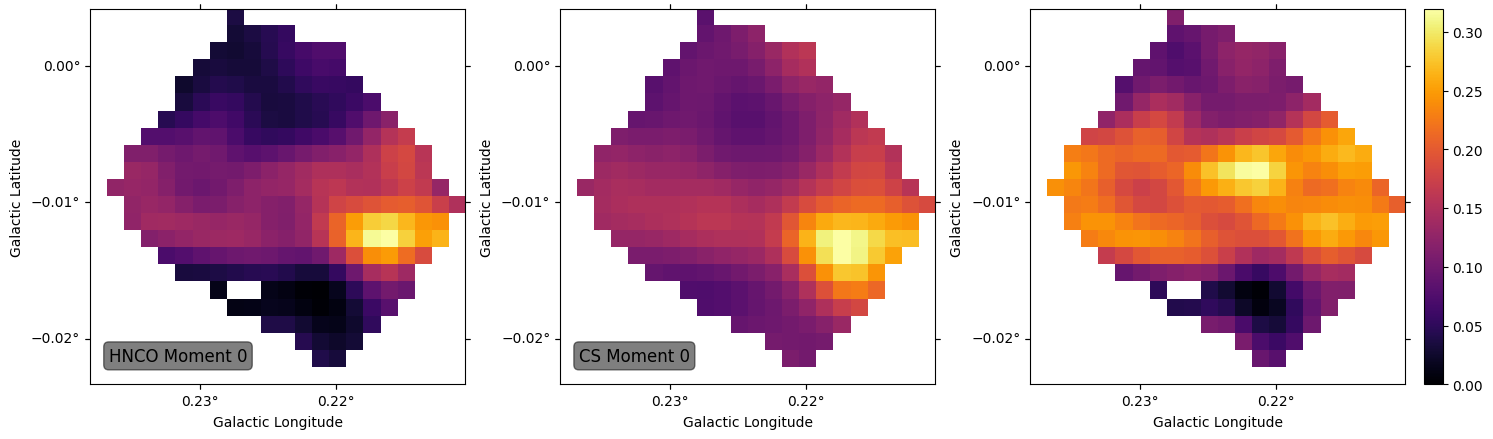

In [62]:
cube_brick_sfluff_HNCO_range1 = cube_brick_sfluff_HNCO.spectral_slab(50*u.km/u.s, 100*u.km/u.s)
cube_brick_sfluff_CS_range1 = cube_brick_sfluff_CS.spectral_slab(50*u.km/u.s, 100*u.km/u.s)

mom0_brick_sfluff_HNCO_range1 = cube_brick_sfluff_HNCO_range1.with_mask(mask_brick_sfluff_HNCO).moment(order=0)
mom0_brick_sfluff_CS_range1 = cube_brick_sfluff_CS_range1.with_mask(mask_brick_sfluff_CS).moment(order=0)

ratio_brick_sfluff_HNCO_CS_range1 = mom0_brick_sfluff_HNCO_range1 / mom0_brick_sfluff_CS_range1

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_brick_sfluff_HNCO_range1.wcs)
ax1.imshow(mom0_brick_sfluff_HNCO_range1.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.05, 0.1, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_brick_sfluff_CS_range1.wcs)
ax2.imshow(mom0_brick_sfluff_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.05, 0.1, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_brick_sfluff_HNCO_CS_range1.wcs)
im = ax3.imshow(ratio_brick_sfluff_HNCO_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

### Brick North Fluff

In [63]:
#reg_brick_nfluff 
cube_brick_nfluff_HNCO = cube_HNCO.subcube_from_regions(reg_brick_nfluff, minimize=False)
spec_brick_nfluff_HNCO = cube_brick_nfluff_HNCO.mean(axis=(1, 2))
cube_brick_nfluff_CS = cube_CS.subcube_from_regions(reg_brick_nfluff, minimize=False)
spec_brick_nfluff_CS = cube_brick_nfluff_CS.mean(axis=(1, 2))
#cube_brick_nfluff_SiO = cube_SiO.subcube_from_regions(reg_brick_nfluff, minimize=False)
#spec_brick_nfluff_SiO = cube_brick_nfluff_SiO.mean(axis=(1, 2))



/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: Mean of empty slice
  out = function(self._get_filled_data(fill=fill,


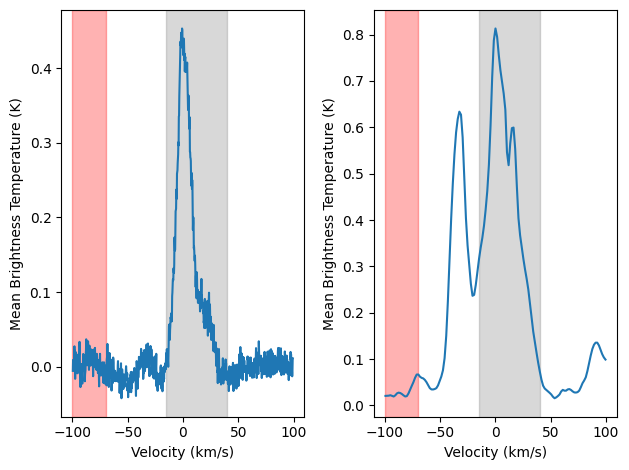

In [64]:
ax1 = plt.subplot(121)
ax1.plot(spec_brick_nfluff_HNCO.spectral_axis, spec_brick_nfluff_HNCO.value, label='HNCO')
ax1.set_xlabel('Velocity (km/s)')
ax1.set_ylabel('Mean Brightness Temperature (K)')

ax2 = plt.subplot(122)
ax2.plot(spec_brick_nfluff_CS.spectral_axis, spec_brick_nfluff_CS.value, label='CS')
ax2.set_xlabel('Velocity (km/s)')
ax2.set_ylabel('Mean Brightness Temperature (K)')

for ax in [ax1, ax2]:
    ax.axvspan(-15, 40, color='gray', alpha=0.3)
    #ax.axvspan(50, 100, color='gray', alpha=0.3)
    ax.axvspan(-100, -70, color='red', alpha=0.3)

plt.tight_layout()

In [65]:
mask_brick_nfluff_HNCO = noise_mask(cube_brick_nfluff_HNCO, -100*u.km/u.s, -70*u.km/u.s, 5)
mask_brick_nfluff_CS = noise_mask(cube_brick_nfluff_CS, -100*u.km/u.s, -70*u.km/u.s, 5)

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,


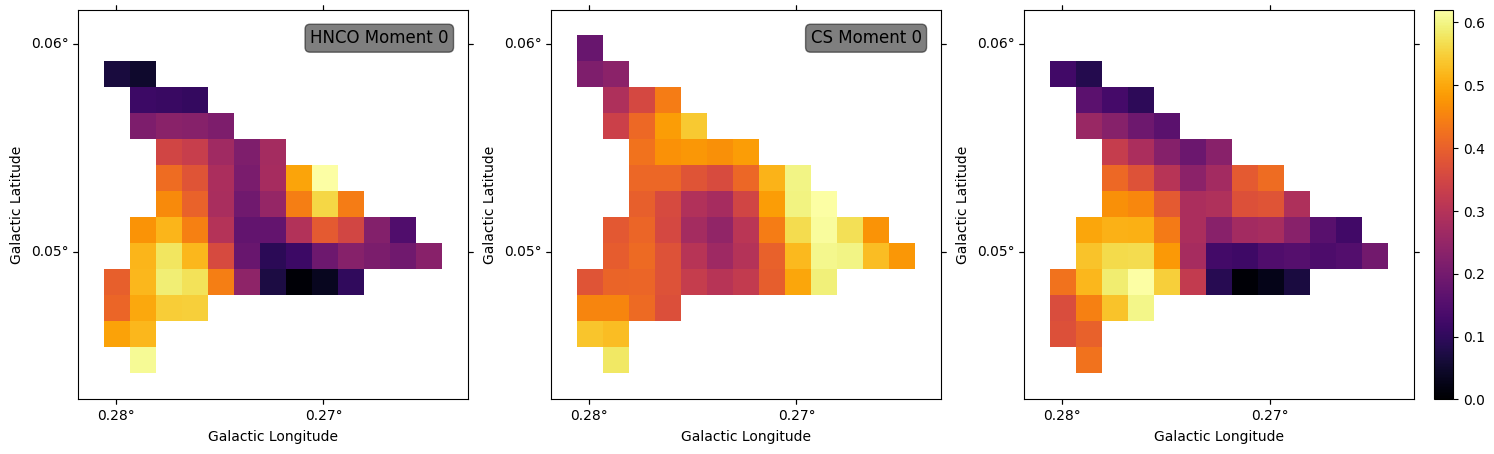

In [66]:
cube_brick_nfluff_HNCO_range1 = cube_brick_nfluff_HNCO.spectral_slab(-15*u.km/u.s, 40*u.km/u.s)
cube_brick_nfluff_CS_range1 = cube_brick_nfluff_CS.spectral_slab(-15*u.km/u.s, 40*u.km/u.s)

mom0_brick_nfluff_HNCO_range1 = cube_brick_nfluff_HNCO_range1.with_mask(mask_brick_nfluff_HNCO).moment(order=0)
mom0_brick_nfluff_CS_range1 = cube_brick_nfluff_CS_range1.with_mask(mask_brick_nfluff_CS).moment(order=0)

ratio_brick_nfluff_HNCO_CS_range1 = mom0_brick_nfluff_HNCO_range1 / mom0_brick_nfluff_CS_range1

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_brick_nfluff_HNCO_range1.wcs)
ax1.imshow(mom0_brick_nfluff_HNCO_range1.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.95, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_brick_nfluff_CS_range1.wcs)
ax2.imshow(mom0_brick_nfluff_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.95, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_brick_nfluff_HNCO_CS_range1.wcs)
im = ax3.imshow(ratio_brick_nfluff_HNCO_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

### Brick SFR

In [67]:
#reg_brick_sfr
cube_brick_sfr_HNCO = cube_HNCO.subcube_from_regions(reg_brick_sfr, minimize=False)
spec_brick_sfr_HNCO = cube_brick_sfr_HNCO.mean(axis=(1, 2))
cube_brick_sfr_CS = cube_CS.subcube_from_regions(reg_brick_sfr, minimize=False)
spec_brick_sfr_CS = cube_brick_sfr_CS.mean(axis=(1, 2))
#cube_brick_sfr_SiO = cube_SiO.subcube_from_regions(reg_brick_sfr, minimize=False)
#spec_brick_sfr_SiO = cube_brick_sfr_SiO.mean(axis=(1, 2))



/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: Mean of empty slice
  out = function(self._get_filled_data(fill=fill,


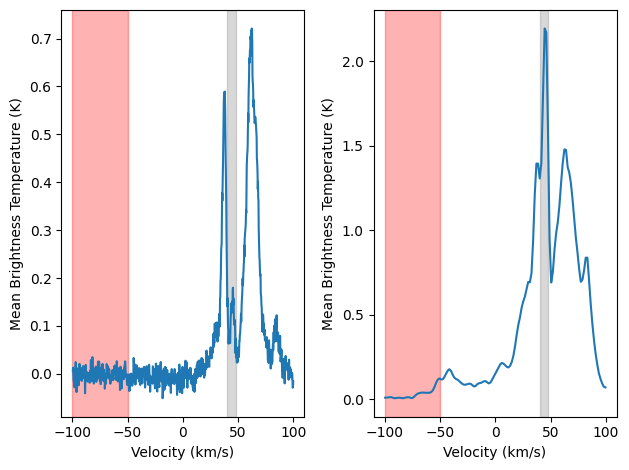

In [68]:
ax1 = plt.subplot(121)
ax1.plot(spec_brick_sfr_HNCO.spectral_axis, spec_brick_sfr_HNCO.value, label='HNCO')
ax1.set_xlabel('Velocity (km/s)')
ax1.set_ylabel('Mean Brightness Temperature (K)')

ax2 = plt.subplot(122)
ax2.plot(spec_brick_sfr_CS.spectral_axis, spec_brick_sfr_CS.value, label='CS')
ax2.set_xlabel('Velocity (km/s)')
ax2.set_ylabel('Mean Brightness Temperature (K)')

for ax in [ax1, ax2]:
    ax.axvspan(40, 48, color='gray', alpha=0.3)
    #ax.axvspan(50, 100, color='gray', alpha=0.3)
    ax.axvspan(-100, -50, color='red', alpha=0.3)

plt.tight_layout()

In [69]:
mask_brick_sfr_HNCO = noise_mask(cube_brick_sfr_HNCO, -100*u.km/u.s, -50*u.km/u.s, 5)
mask_brick_sfr_CS = noise_mask(cube_brick_sfr_CS, -100*u.km/u.s, -50*u.km/u.s, 5)

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,


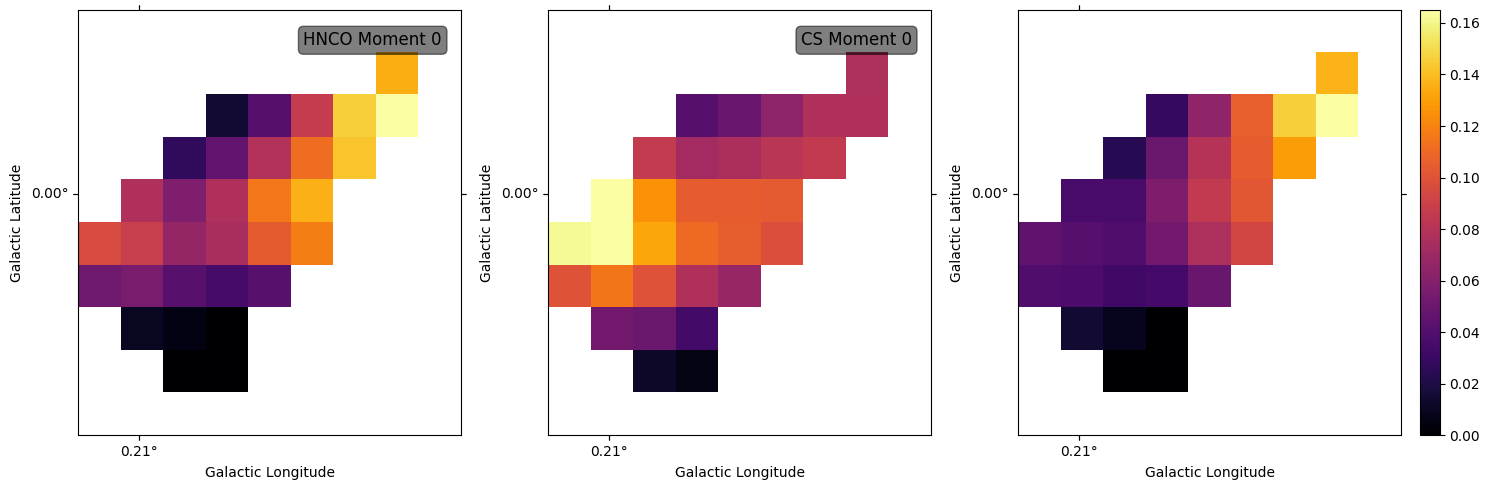

In [70]:
cube_brick_sfr_HNCO_range1 = cube_brick_sfr_HNCO.spectral_slab(40*u.km/u.s, 48*u.km/u.s)
cube_brick_sfr_CS_range1 = cube_brick_sfr_CS.spectral_slab(40*u.km/u.s, 48*u.km/u.s)

mom0_brick_sfr_HNCO_range1 = cube_brick_sfr_HNCO_range1.with_mask(mask_brick_sfr_HNCO).moment(order=0)
mom0_brick_sfr_CS_range1 = cube_brick_sfr_CS_range1.with_mask(mask_brick_sfr_CS).moment(order=0)

ratio_brick_sfr_HNCO_CS_range1 = mom0_brick_sfr_HNCO_range1 / mom0_brick_sfr_CS_range1

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_brick_sfr_HNCO_range1.wcs)
ax1.imshow(mom0_brick_sfr_HNCO_range1.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.95, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_brick_sfr_CS_range1.wcs)
ax2.imshow(mom0_brick_sfr_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.95, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_brick_sfr_HNCO_CS_range1.wcs)
im = ax3.imshow(ratio_brick_sfr_HNCO_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

### Brick SFR Wide

In [71]:
#reg_brick_sfrwide 
cube_brick_sfrwide_HNCO = cube_HNCO.subcube_from_regions(reg_brick_sfrwide, minimize=False)
spec_brick_sfrwide_HNCO = cube_brick_sfrwide_HNCO.mean(axis=(1, 2))
cube_brick_sfrwide_CS = cube_CS.subcube_from_regions(reg_brick_sfrwide, minimize=False)
spec_brick_sfrwide_CS = cube_brick_sfrwide_CS.mean(axis=(1, 2))
#cube_brick_sfrwide_SiO = cube_SiO.subcube_from_regions(reg_brick_sfrwide, minimize=False)
#spec_brick_sfrwide_SiO = cube_brick_sfrwide_SiO.mean(axis=(1, 2))



/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: Mean of empty slice
  out = function(self._get_filled_data(fill=fill,


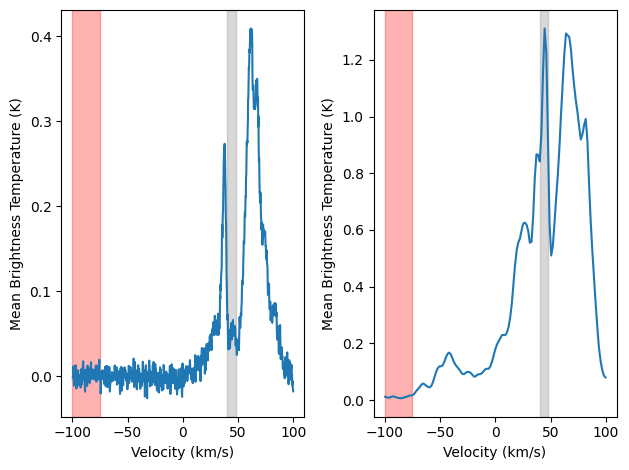

In [72]:
ax1 = plt.subplot(121)
ax1.plot(spec_brick_sfrwide_HNCO.spectral_axis, spec_brick_sfrwide_HNCO.value, label='HNCO')
ax1.set_xlabel('Velocity (km/s)')
ax1.set_ylabel('Mean Brightness Temperature (K)')

ax2 = plt.subplot(122)
ax2.plot(spec_brick_sfrwide_CS.spectral_axis, spec_brick_sfrwide_CS.value, label='CS')
ax2.set_xlabel('Velocity (km/s)')
ax2.set_ylabel('Mean Brightness Temperature (K)')

for ax in [ax1, ax2]:
    ax.axvspan(40, 48, color='gray', alpha=0.3)
    #ax.axvspan(50, 100, color='gray', alpha=0.3)
    ax.axvspan(-100, -75, color='red', alpha=0.3)

plt.tight_layout()

In [73]:
mask_brick_sfrwide_HNCO = noise_mask(cube_brick_sfrwide_HNCO, -100*u.km/u.s, -75*u.km/u.s, 5)
mask_brick_sfrwide_CS = noise_mask(cube_brick_sfrwide_CS, -100*u.km/u.s, -75*u.km/u.s, 5)

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,


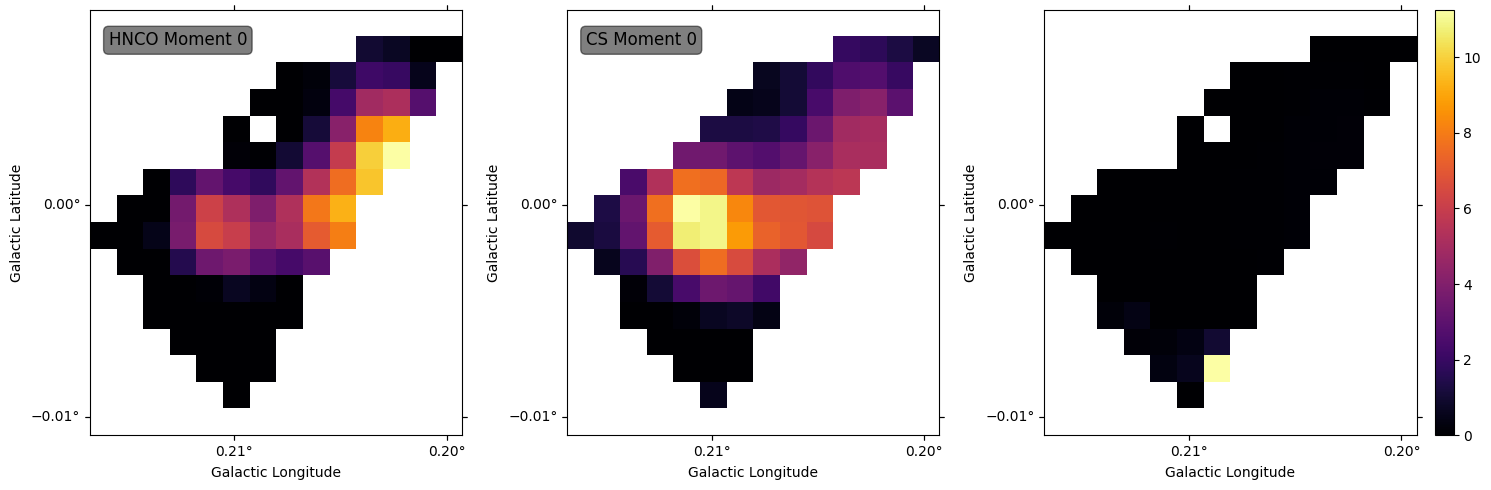

In [74]:
cube_brick_sfrwide_HNCO_range1 = cube_brick_sfrwide_HNCO.spectral_slab(40*u.km/u.s, 48*u.km/u.s)
cube_brick_sfrwide_CS_range1 = cube_brick_sfrwide_CS.spectral_slab(40*u.km/u.s, 48*u.km/u.s)

mom0_brick_sfrwide_HNCO_range1 = cube_brick_sfrwide_HNCO_range1.with_mask(mask_brick_sfrwide_HNCO).moment(order=0)
mom0_brick_sfrwide_CS_range1 = cube_brick_sfrwide_CS_range1.with_mask(mask_brick_sfrwide_CS).moment(order=0)

ratio_brick_sfrwide_HNCO_CS_range1 = mom0_brick_sfrwide_HNCO_range1 / mom0_brick_sfrwide_CS_range1

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_brick_sfrwide_HNCO_range1.wcs)
ax1.imshow(mom0_brick_sfrwide_HNCO_range1.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.05, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_brick_sfrwide_CS_range1.wcs)
ax2.imshow(mom0_brick_sfrwide_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.05, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_brick_sfrwide_HNCO_CS_range1.wcs)
im = ax3.imshow(ratio_brick_sfrwide_HNCO_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

### Brick Punch

In [75]:
#reg_brick_punch 
cube_brick_punch_HNCO = cube_HNCO.subcube_from_regions(reg_brick_punch, minimize=False)
spec_brick_punch_HNCO = cube_brick_punch_HNCO.mean(axis=(1, 2))
cube_brick_punch_CS = cube_CS.subcube_from_regions(reg_brick_punch, minimize=False)
spec_brick_punch_CS = cube_brick_punch_CS.mean(axis=(1, 2))
#cube_brick_punch_SiO = cube_SiO.subcube_from_regions(reg_brick_punch, minimize=False)
#spec_brick_punch_SiO = cube_brick_punch_SiO.mean(axis=(1, 2))



/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: Mean of empty slice
  out = function(self._get_filled_data(fill=fill,


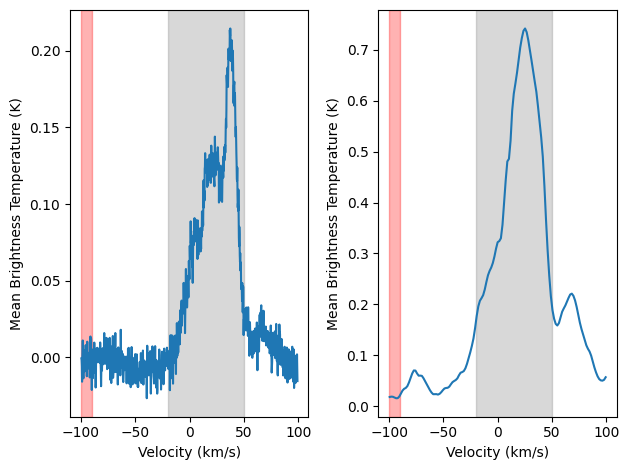

In [76]:
ax1 = plt.subplot(121)
ax1.plot(spec_brick_punch_HNCO.spectral_axis, spec_brick_punch_HNCO.value, label='HNCO')
ax1.set_xlabel('Velocity (km/s)')
ax1.set_ylabel('Mean Brightness Temperature (K)')

ax2 = plt.subplot(122)
ax2.plot(spec_brick_punch_CS.spectral_axis, spec_brick_punch_CS.value, label='CS')
ax2.set_xlabel('Velocity (km/s)')
ax2.set_ylabel('Mean Brightness Temperature (K)')

for ax in [ax1, ax2]:
    ax.axvspan(-20, 50, color='gray', alpha=0.3)
    #ax.axvspan(50, 100, color='gray', alpha=0.3)
    ax.axvspan(-100, -90, color='red', alpha=0.3)

plt.tight_layout()

In [77]:
mask_brick_punch_HNCO = noise_mask(cube_brick_punch_HNCO, -100*u.km/u.s, -90*u.km/u.s, 5)
mask_brick_punch_CS = noise_mask(cube_brick_punch_CS, -100*u.km/u.s, -90*u.km/u.s, 5)

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,


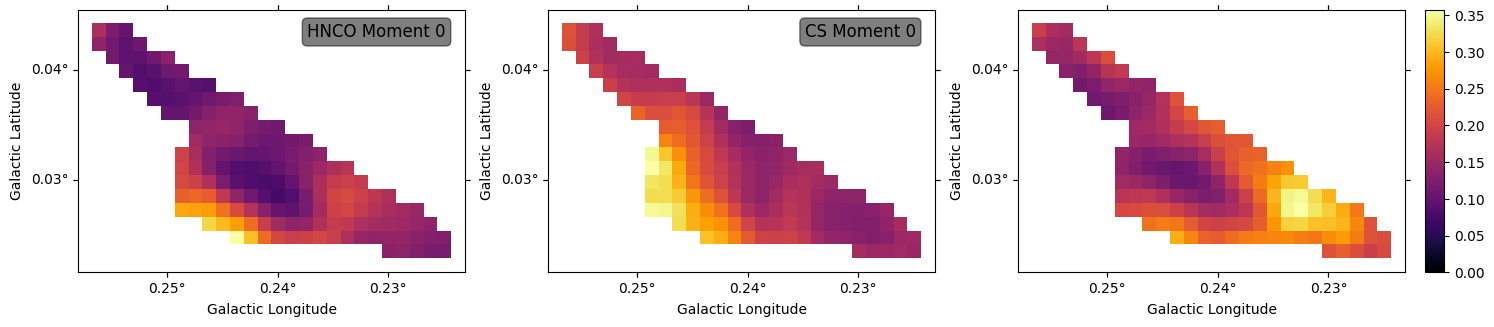

In [78]:
cube_brick_punch_HNCO_range1 = cube_brick_punch_HNCO.spectral_slab(-20*u.km/u.s, 50*u.km/u.s)
cube_brick_punch_CS_range1 = cube_brick_punch_CS.spectral_slab(-20*u.km/u.s, 50*u.km/u.s)

mom0_brick_punch_HNCO_range1 = cube_brick_punch_HNCO_range1.with_mask(mask_brick_punch_HNCO).moment(order=0)
mom0_brick_punch_CS_range1 = cube_brick_punch_CS_range1.with_mask(mask_brick_punch_CS).moment(order=0)

ratio_brick_punch_HNCO_CS_range1 = mom0_brick_punch_HNCO_range1 / mom0_brick_punch_CS_range1

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_brick_punch_HNCO_range1.wcs)
ax1.imshow(mom0_brick_punch_HNCO_range1.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.95, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_brick_punch_CS_range1.wcs)
ax2.imshow(mom0_brick_punch_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.95, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_brick_punch_HNCO_CS_range1.wcs)
im = ax3.imshow(ratio_brick_punch_HNCO_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

### Brick South Fore

In [79]:
#reg_brick_sfore 
cube_brick_sfore_HNCO = cube_HNCO.subcube_from_regions(reg_brick_sfore, minimize=False)
spec_brick_sfore_HNCO = cube_brick_sfore_HNCO.mean(axis=(1, 2))
cube_brick_sfore_CS = cube_CS.subcube_from_regions(reg_brick_sfore, minimize=False)
spec_brick_sfore_CS = cube_brick_sfore_CS.mean(axis=(1, 2))
#cube_brick_sfore_SiO = cube_SiO.subcube_from_regions(reg_brick_sfore, minimize=False)
#spec_brick_sfore_SiO = cube_brick_sfore_SiO.mean(axis=(1, 2))



/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: Mean of empty slice
  out = function(self._get_filled_data(fill=fill,


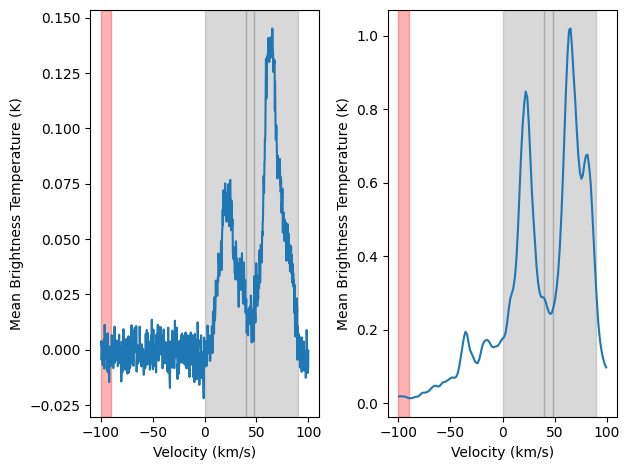

In [80]:
ax1 = plt.subplot(121)
ax1.plot(spec_brick_sfore_HNCO.spectral_axis, spec_brick_sfore_HNCO.value, label='HNCO')
ax1.set_xlabel('Velocity (km/s)')
ax1.set_ylabel('Mean Brightness Temperature (K)')

ax2 = plt.subplot(122)
ax2.plot(spec_brick_sfore_CS.spectral_axis, spec_brick_sfore_CS.value, label='CS')
ax2.set_xlabel('Velocity (km/s)')
ax2.set_ylabel('Mean Brightness Temperature (K)')

for ax in [ax1, ax2]:
    ax.axvspan(40, 48, color='gray', alpha=0.3)
    ax.axvspan(0, 40, color='gray', alpha=0.3)
    ax.axvspan(48, 90, color='gray', alpha=0.3)
    #ax.axvspan(50, 100, color='gray', alpha=0.3)
    ax.axvspan(-100, -90, color='red', alpha=0.3)

plt.tight_layout()

In [81]:
mask_brick_sfore_HNCO = noise_mask(cube_brick_sfore_HNCO, -100*u.km/u.s, -90*u.km/u.s, 5)
mask_brick_sfore_CS = noise_mask(cube_brick_sfore_CS, -100*u.km/u.s, -90*u.km/u.s, 5)

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,


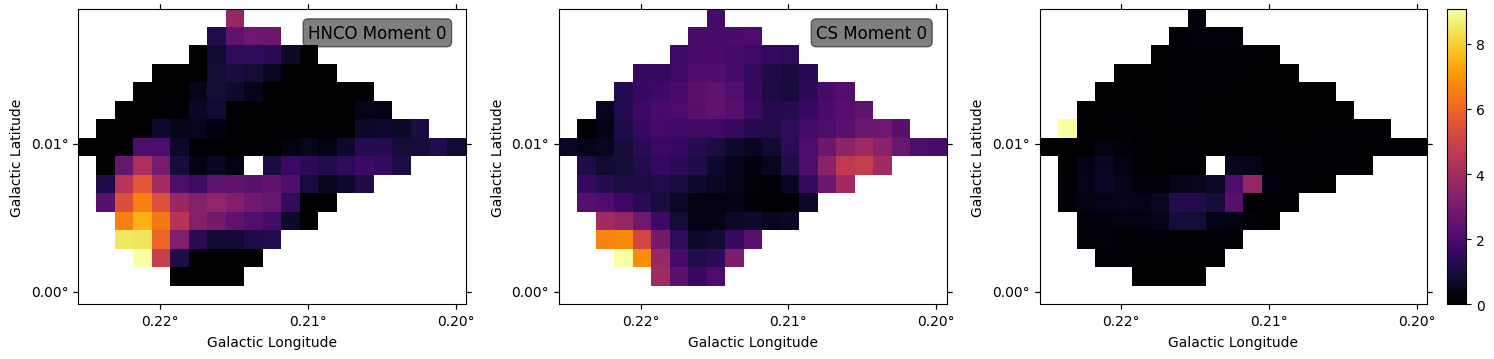

In [82]:
cube_brick_sfore_HNCO_range1 = cube_brick_sfore_HNCO.spectral_slab(40*u.km/u.s, 48*u.km/u.s)
cube_brick_sfore_CS_range1 = cube_brick_sfore_CS.spectral_slab(40*u.km/u.s, 48*u.km/u.s)

mom0_brick_sfore_HNCO_range1 = cube_brick_sfore_HNCO_range1.with_mask(mask_brick_sfore_HNCO).moment(order=0)
mom0_brick_sfore_CS_range1 = cube_brick_sfore_CS_range1.with_mask(mask_brick_sfore_CS).moment(order=0)

ratio_brick_sfore_HNCO_CS_range1 = mom0_brick_sfore_HNCO_range1 / mom0_brick_sfore_CS_range1

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_brick_sfore_HNCO_range1.wcs)
ax1.imshow(mom0_brick_sfore_HNCO_range1.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.95, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_brick_sfore_CS_range1.wcs)
ax2.imshow(mom0_brick_sfore_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.95, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_brick_sfore_HNCO_CS_range1.wcs)
im = ax3.imshow(ratio_brick_sfore_HNCO_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

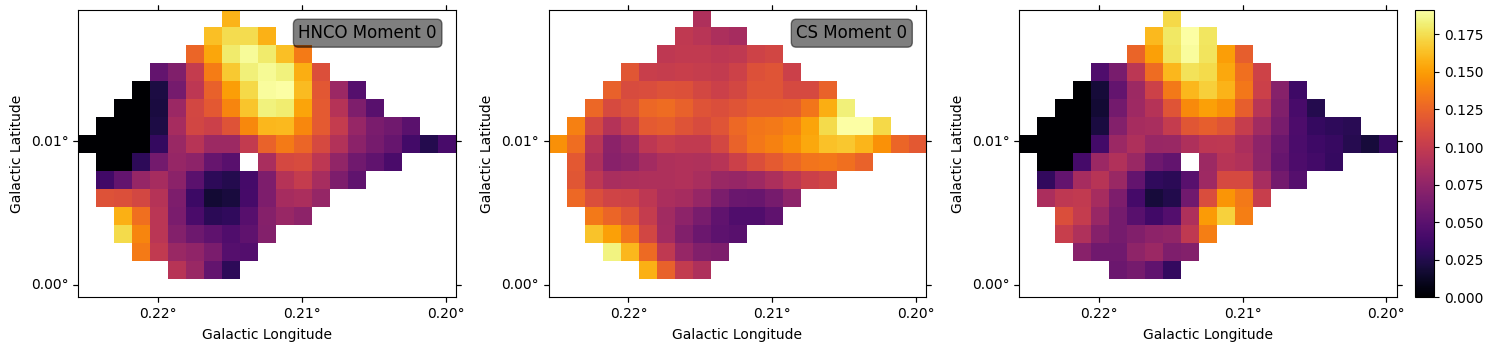

In [83]:
cube_brick_sfore_HNCO_range2 = cube_brick_sfore_HNCO.spectral_slab(0*u.km/u.s, 40*u.km/u.s)
cube_brick_sfore_CS_range2 = cube_brick_sfore_CS.spectral_slab(0*u.km/u.s, 40*u.km/u.s)

mom0_brick_sfore_HNCO_range2 = cube_brick_sfore_HNCO_range2.with_mask(mask_brick_sfore_HNCO).moment(order=0)
mom0_brick_sfore_CS_range2 = cube_brick_sfore_CS_range2.with_mask(mask_brick_sfore_CS).moment(order=0)

ratio_brick_sfore_HNCO_CS_range2 = mom0_brick_sfore_HNCO_range2 / mom0_brick_sfore_CS_range2

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_brick_sfore_HNCO_range2.wcs)
ax1.imshow(mom0_brick_sfore_HNCO_range2.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.95, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_brick_sfore_CS_range2.wcs)
ax2.imshow(mom0_brick_sfore_CS_range2.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.95, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_brick_sfore_HNCO_CS_range2.wcs)
im = ax3.imshow(ratio_brick_sfore_HNCO_CS_range2.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

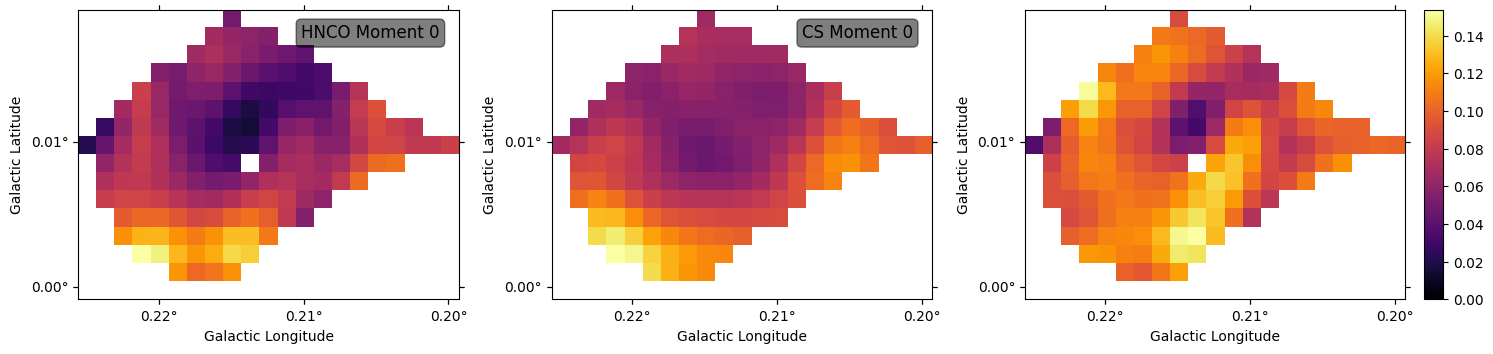

In [84]:
cube_brick_sfore_HNCO_range3 = cube_brick_sfore_HNCO.spectral_slab(40*u.km/u.s, 90*u.km/u.s)
cube_brick_sfore_CS_range3 = cube_brick_sfore_CS.spectral_slab(40*u.km/u.s, 90*u.km/u.s)

mom0_brick_sfore_HNCO_range3 = cube_brick_sfore_HNCO_range3.with_mask(mask_brick_sfore_HNCO).moment(order=0)
mom0_brick_sfore_CS_range3 = cube_brick_sfore_CS_range3.with_mask(mask_brick_sfore_CS).moment(order=0)

ratio_brick_sfore_HNCO_CS_range3 = mom0_brick_sfore_HNCO_range3 / mom0_brick_sfore_CS_range3

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_brick_sfore_HNCO_range3.wcs)
ax1.imshow(mom0_brick_sfore_HNCO_range3.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.95, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_brick_sfore_CS_range3.wcs)
ax2.imshow(mom0_brick_sfore_CS_range3.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.95, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_brick_sfore_HNCO_CS_range3.wcs)
im = ax3.imshow(ratio_brick_sfore_HNCO_CS_range3.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

### Brick North Clear

In [85]:
#reg_brick_nclear
cube_brick_nclear_HNCO = cube_HNCO.subcube_from_regions(reg_brick_nclear, minimize=False)
spec_brick_nclear_HNCO = cube_brick_nclear_HNCO.mean(axis=(1, 2))
cube_brick_nclear_CS = cube_CS.subcube_from_regions(reg_brick_nclear, minimize=False)
spec_brick_nclear_CS = cube_brick_nclear_CS.mean(axis=(1, 2))
#cube_brick_nclear_SiO = cube_SiO.subcube_from_regions(reg_brick_nclear, minimize=False)
#spec_brick_nclear_SiO = cube_brick_nclear_SiO.mean(axis=(1, 2))



/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: Mean of empty slice
  out = function(self._get_filled_data(fill=fill,


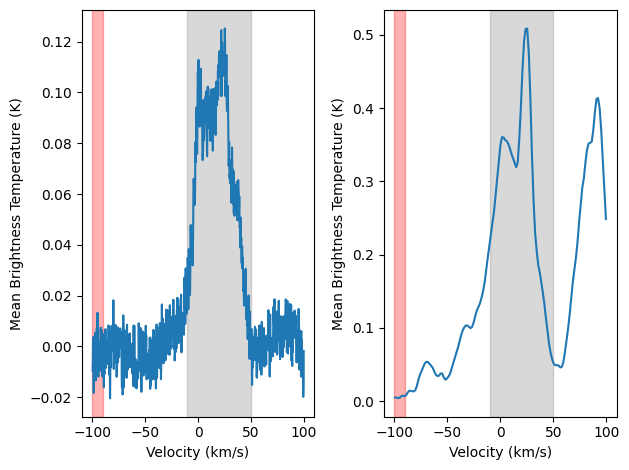

In [86]:
ax1 = plt.subplot(121)
ax1.plot(spec_brick_nclear_HNCO.spectral_axis, spec_brick_nclear_HNCO.value, label='HNCO')
ax1.set_xlabel('Velocity (km/s)')
ax1.set_ylabel('Mean Brightness Temperature (K)')

ax2 = plt.subplot(122)
ax2.plot(spec_brick_nclear_CS.spectral_axis, spec_brick_nclear_CS.value, label='CS')
ax2.set_xlabel('Velocity (km/s)')
ax2.set_ylabel('Mean Brightness Temperature (K)')

for ax in [ax1, ax2]:
    ax.axvspan(-10, 50, color='gray', alpha=0.3)
    #ax.axvspan(50, 100, color='gray', alpha=0.3)
    ax.axvspan(-100, -90, color='red', alpha=0.3)

plt.tight_layout()

In [87]:
mask_brick_nclear_HNCO = noise_mask(cube_brick_nclear_HNCO, -100*u.km/u.s, -90*u.km/u.s, 5)
mask_brick_nclear_CS = noise_mask(cube_brick_nclear_CS, -100*u.km/u.s, -90*u.km/u.s, 5)

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,


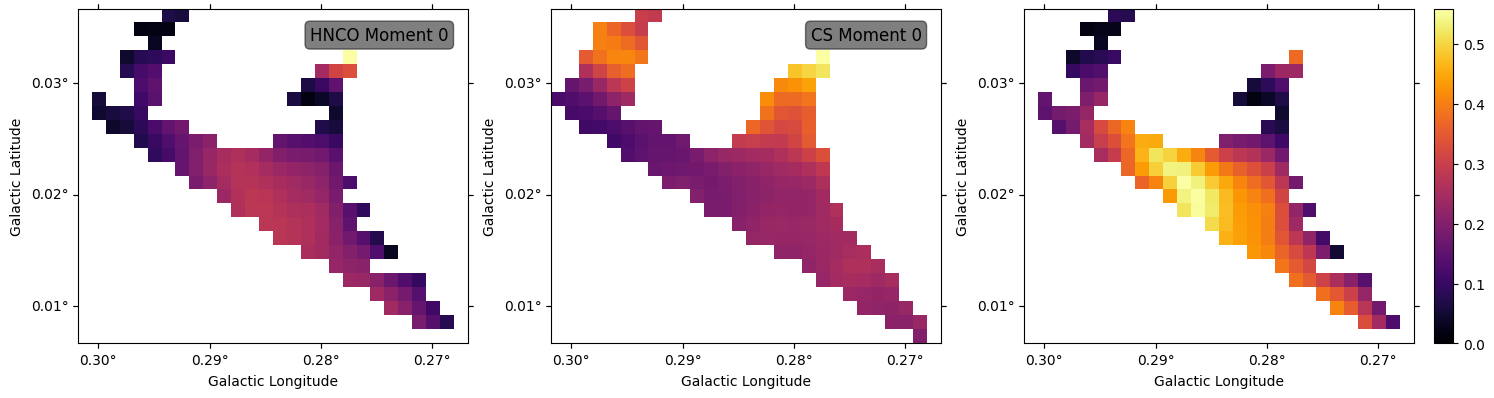

In [88]:
cube_brick_nclear_HNCO_range1 = cube_brick_nclear_HNCO.spectral_slab(-10*u.km/u.s, 50*u.km/u.s)
cube_brick_nclear_CS_range1 = cube_brick_nclear_CS.spectral_slab(-10*u.km/u.s, 50*u.km/u.s)

mom0_brick_nclear_HNCO_range1 = cube_brick_nclear_HNCO_range1.with_mask(mask_brick_nclear_HNCO).moment(order=0)
mom0_brick_nclear_CS_range1 = cube_brick_nclear_CS_range1.with_mask(mask_brick_nclear_CS).moment(order=0)

ratio_brick_nclear_HNCO_CS_range1 = mom0_brick_nclear_HNCO_range1 / mom0_brick_nclear_CS_range1

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_brick_nclear_HNCO_range1.wcs)
ax1.imshow(mom0_brick_nclear_HNCO_range1.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.95, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_brick_nclear_CS_range1.wcs)
ax2.imshow(mom0_brick_nclear_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.95, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_brick_nclear_HNCO_CS_range1.wcs)
im = ax3.imshow(ratio_brick_nclear_HNCO_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

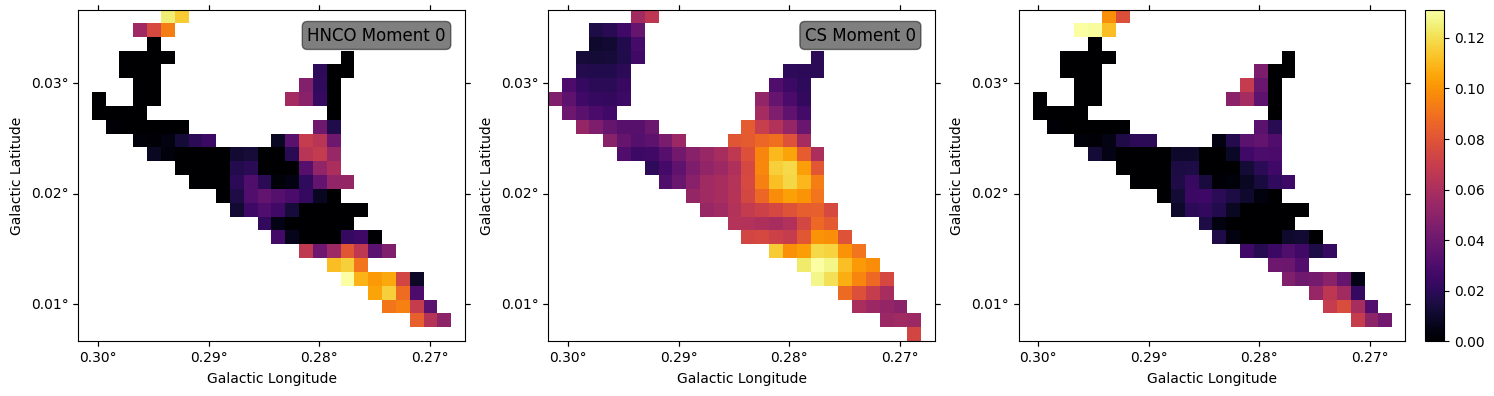

In [89]:
cube_brick_nclear_HNCO_range2 = cube_brick_nclear_HNCO.spectral_slab(50*u.km/u.s, 100*u.km/u.s)
cube_brick_nclear_CS_range2 = cube_brick_nclear_CS.spectral_slab(50*u.km/u.s, 100*u.km/u.s)

mom0_brick_nclear_HNCO_range2 = cube_brick_nclear_HNCO_range2.with_mask(mask_brick_nclear_HNCO).moment(order=0)
mom0_brick_nclear_CS_range2 = cube_brick_nclear_CS_range2.with_mask(mask_brick_nclear_CS).moment(order=0)

ratio_brick_nclear_HNCO_CS_range2 = mom0_brick_nclear_HNCO_range2 / mom0_brick_nclear_CS_range2

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_brick_nclear_HNCO_range2.wcs)
ax1.imshow(mom0_brick_nclear_HNCO_range2.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.95, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_brick_nclear_CS_range2.wcs)
ax2.imshow(mom0_brick_nclear_CS_range2.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.95, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_brick_nclear_HNCO_CS_range2.wcs)
im = ax3.imshow(ratio_brick_nclear_HNCO_CS_range2.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

### Brick Top C

In [90]:
#reg_brick_topc
cube_brick_topc_HNCO = cube_HNCO.subcube_from_regions(reg_brick_topc, minimize=False)
spec_brick_topc_HNCO = cube_brick_topc_HNCO.mean(axis=(1, 2))
cube_brick_topc_CS = cube_CS.subcube_from_regions(reg_brick_topc, minimize=False)
spec_brick_topc_CS = cube_brick_topc_CS.mean(axis=(1, 2))
#cube_brick_topc_SiO = cube_SiO.subcube_from_regions(reg_brick_topc, minimize=False)
#spec_brick_topc_SiO = cube_brick_topc_SiO.mean(axis=(1, 2))



/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: Mean of empty slice
  out = function(self._get_filled_data(fill=fill,


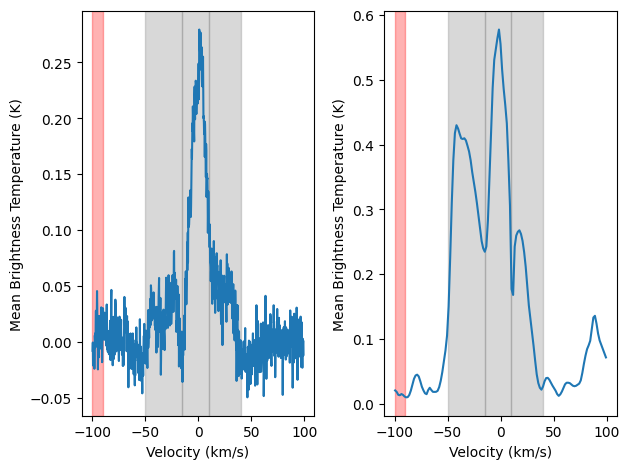

In [91]:
ax1 = plt.subplot(121)
ax1.plot(spec_brick_topc_HNCO.spectral_axis, spec_brick_topc_HNCO.value, label='HNCO')
ax1.set_xlabel('Velocity (km/s)')
ax1.set_ylabel('Mean Brightness Temperature (K)')

ax2 = plt.subplot(122)
ax2.plot(spec_brick_topc_CS.spectral_axis, spec_brick_topc_CS.value, label='CS')
ax2.set_xlabel('Velocity (km/s)')
ax2.set_ylabel('Mean Brightness Temperature (K)')

for ax in [ax1, ax2]:
    ax.axvspan(-15, 10, color='gray', alpha=0.3)
    ax.axvspan(-50, -15, color='gray', alpha=0.3)
    ax.axvspan(10, 40, color='gray', alpha=0.3)
    #ax.axvspan(50, 100, color='gray', alpha=0.3)
    ax.axvspan(-100, -90, color='red', alpha=0.3)

plt.tight_layout()

In [92]:
mask_brick_topc_HNCO = noise_mask(cube_brick_topc_HNCO, -100*u.km/u.s, -90*u.km/u.s, 5)
mask_brick_topc_CS = noise_mask(cube_brick_topc_CS, -100*u.km/u.s, -90*u.km/u.s, 5)

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/adamginsburg/adamginsburg/repos/spectral-cube/spectral_cube/spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,


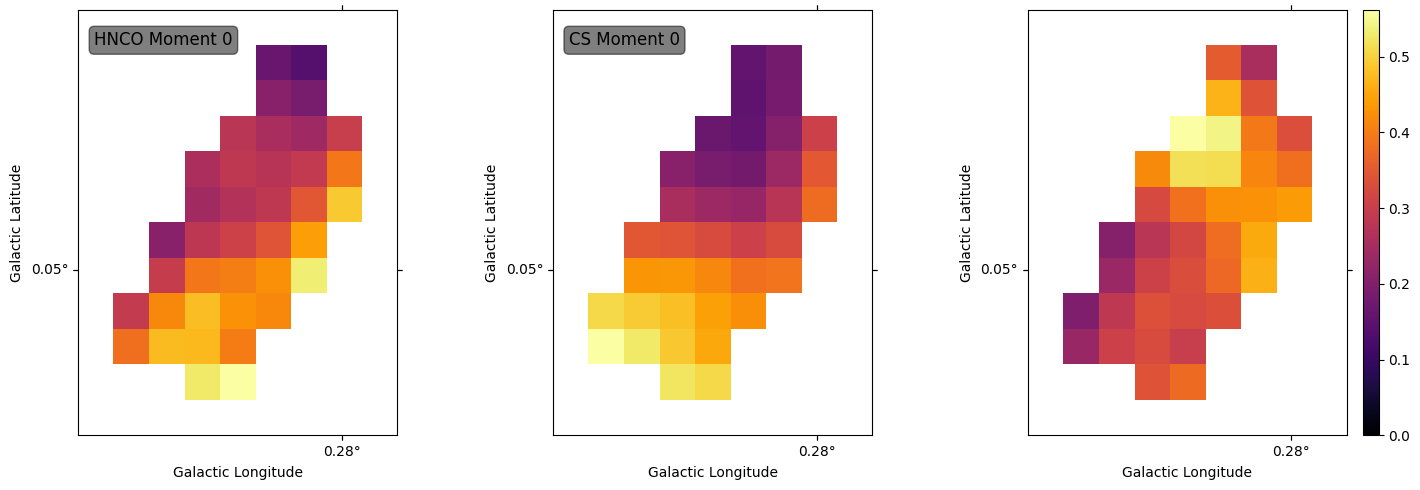

In [93]:
cube_brick_topc_HNCO_range1 = cube_brick_topc_HNCO.spectral_slab(-15*u.km/u.s, 10*u.km/u.s)
cube_brick_topc_CS_range1 = cube_brick_topc_CS.spectral_slab(-15*u.km/u.s, 10*u.km/u.s)

mom0_brick_topc_HNCO_range1 = cube_brick_topc_HNCO_range1.with_mask(mask_brick_topc_HNCO).moment(order=0)
mom0_brick_topc_CS_range1 = cube_brick_topc_CS_range1.with_mask(mask_brick_topc_CS).moment(order=0)

ratio_brick_topc_HNCO_CS_range1 = mom0_brick_topc_HNCO_range1 / mom0_brick_topc_CS_range1

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_brick_topc_HNCO_range1.wcs)
ax1.imshow(mom0_brick_topc_HNCO_range1.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.05, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_brick_topc_CS_range1.wcs)
ax2.imshow(mom0_brick_topc_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.05, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_brick_topc_HNCO_CS_range1.wcs)
im = ax3.imshow(ratio_brick_topc_HNCO_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

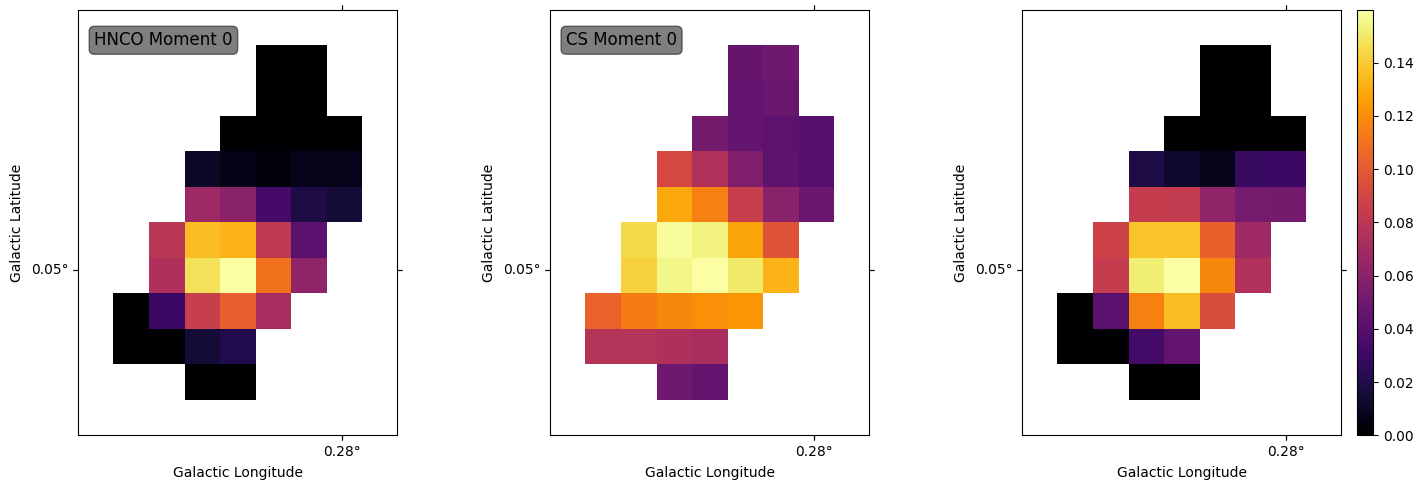

In [94]:
cube_brick_topc_HNCO_range1 = cube_brick_topc_HNCO.spectral_slab(-50*u.km/u.s, -15*u.km/u.s)
cube_brick_topc_CS_range1 = cube_brick_topc_CS.spectral_slab(-50*u.km/u.s, -15*u.km/u.s)

mom0_brick_topc_HNCO_range1 = cube_brick_topc_HNCO_range1.with_mask(mask_brick_topc_HNCO).moment(order=0)
mom0_brick_topc_CS_range1 = cube_brick_topc_CS_range1.with_mask(mask_brick_topc_CS).moment(order=0)

ratio_brick_topc_HNCO_CS_range1 = mom0_brick_topc_HNCO_range1 / mom0_brick_topc_CS_range1

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_brick_topc_HNCO_range1.wcs)
ax1.imshow(mom0_brick_topc_HNCO_range1.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.05, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_brick_topc_CS_range1.wcs)
ax2.imshow(mom0_brick_topc_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.05, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_brick_topc_HNCO_CS_range1.wcs)
im = ax3.imshow(ratio_brick_topc_HNCO_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

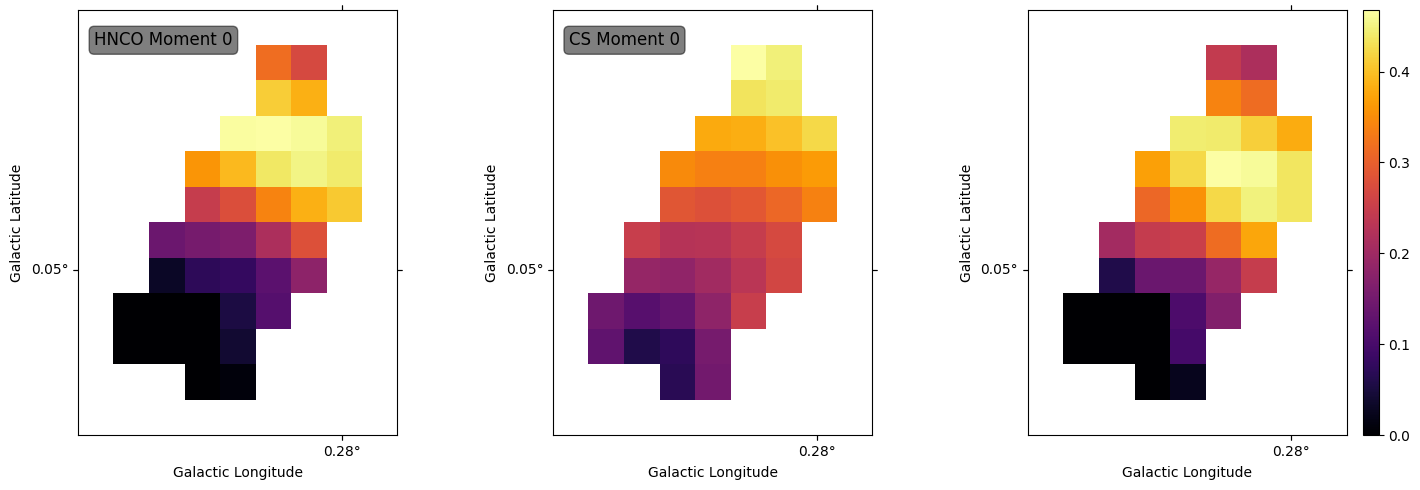

In [95]:
cube_brick_topc_HNCO_range1 = cube_brick_topc_HNCO.spectral_slab(10*u.km/u.s, 40*u.km/u.s)
cube_brick_topc_CS_range1 = cube_brick_topc_CS.spectral_slab(10*u.km/u.s, 40*u.km/u.s)

mom0_brick_topc_HNCO_range1 = cube_brick_topc_HNCO_range1.with_mask(mask_brick_topc_HNCO).moment(order=0)
mom0_brick_topc_CS_range1 = cube_brick_topc_CS_range1.with_mask(mask_brick_topc_CS).moment(order=0)

ratio_brick_topc_HNCO_CS_range1 = mom0_brick_topc_HNCO_range1 / mom0_brick_topc_CS_range1

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(131, projection=mom0_brick_topc_HNCO_range1.wcs)
ax1.imshow(mom0_brick_topc_HNCO_range1.value, origin='lower', cmap='inferno', vmin=0)
ax1.coords[0].set_major_formatter('d.dd')
ax1.coords[1].set_major_formatter('d.dd')
ax1.set_xlabel('Galactic Longitude')
ax1.set_ylabel('Galactic Latitude')
ax1.text(0.05, 0.95, 'HNCO Moment 0', transform=ax1.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax2 = plt.subplot(132, projection=mom0_brick_topc_CS_range1.wcs)
ax2.imshow(mom0_brick_topc_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax2.coords[0].set_major_formatter('d.dd')
ax2.coords[1].set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')
ax2.text(0.05, 0.95, 'CS Moment 0', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='k', alpha=0.5))

ax3 = plt.subplot(133, projection=ratio_brick_topc_HNCO_CS_range1.wcs)
im = ax3.imshow(ratio_brick_topc_HNCO_CS_range1.value, origin='lower', cmap='inferno', vmin=0)
ax3.coords[0].set_major_formatter('d.dd')
ax3.coords[1].set_major_formatter('d.dd')
ax3.set_xlabel('Galactic Longitude')
ax3.set_ylabel('Galactic Latitude')
cax = ax3.inset_axes([1.05, 0.0, 0.05, 1], transform=ax3.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='vertical')#, label='HNCO / CS Ratio')

plt.tight_layout()

### Summary

In [99]:
spectra_brick_HNCO = [spec_brick_north_HNCO, spec_brick_south_HNCO, spec_brick_head_HNCO, spec_brick_sfluff_HNCO, spec_brick_nfluff_HNCO, spec_brick_sfr_HNCO, spec_brick_sfrwide_HNCO, spec_brick_punch_HNCO, spec_brick_sfore_HNCO, spec_brick_nclear_HNCO, spec_brick_topc_HNCO] 
spectra_brick_CS = [spec_brick_north_CS, spec_brick_south_CS, spec_brick_head_CS, spec_brick_sfluff_CS, spec_brick_nfluff_CS, spec_brick_sfr_CS, spec_brick_sfrwide_CS, spec_brick_punch_CS, spec_brick_sfore_CS, spec_brick_nclear_CS, spec_brick_topc_CS] 
#spectra_brick_SiO = [spec_brick_north_SiO, spec_brick_south_SiO, spec_brick_head_SiO, spec_brick_sfluff_SiO, spec_brick_nfluff_SiO, spec_brick_sfr_SiO, spec_brick_sfrwide_SiO, spec_brick_punch_SiO, spec_brick_sfore_SiO, spec_brick_nclear_SiO, spec_brick_topc_SiO] 


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

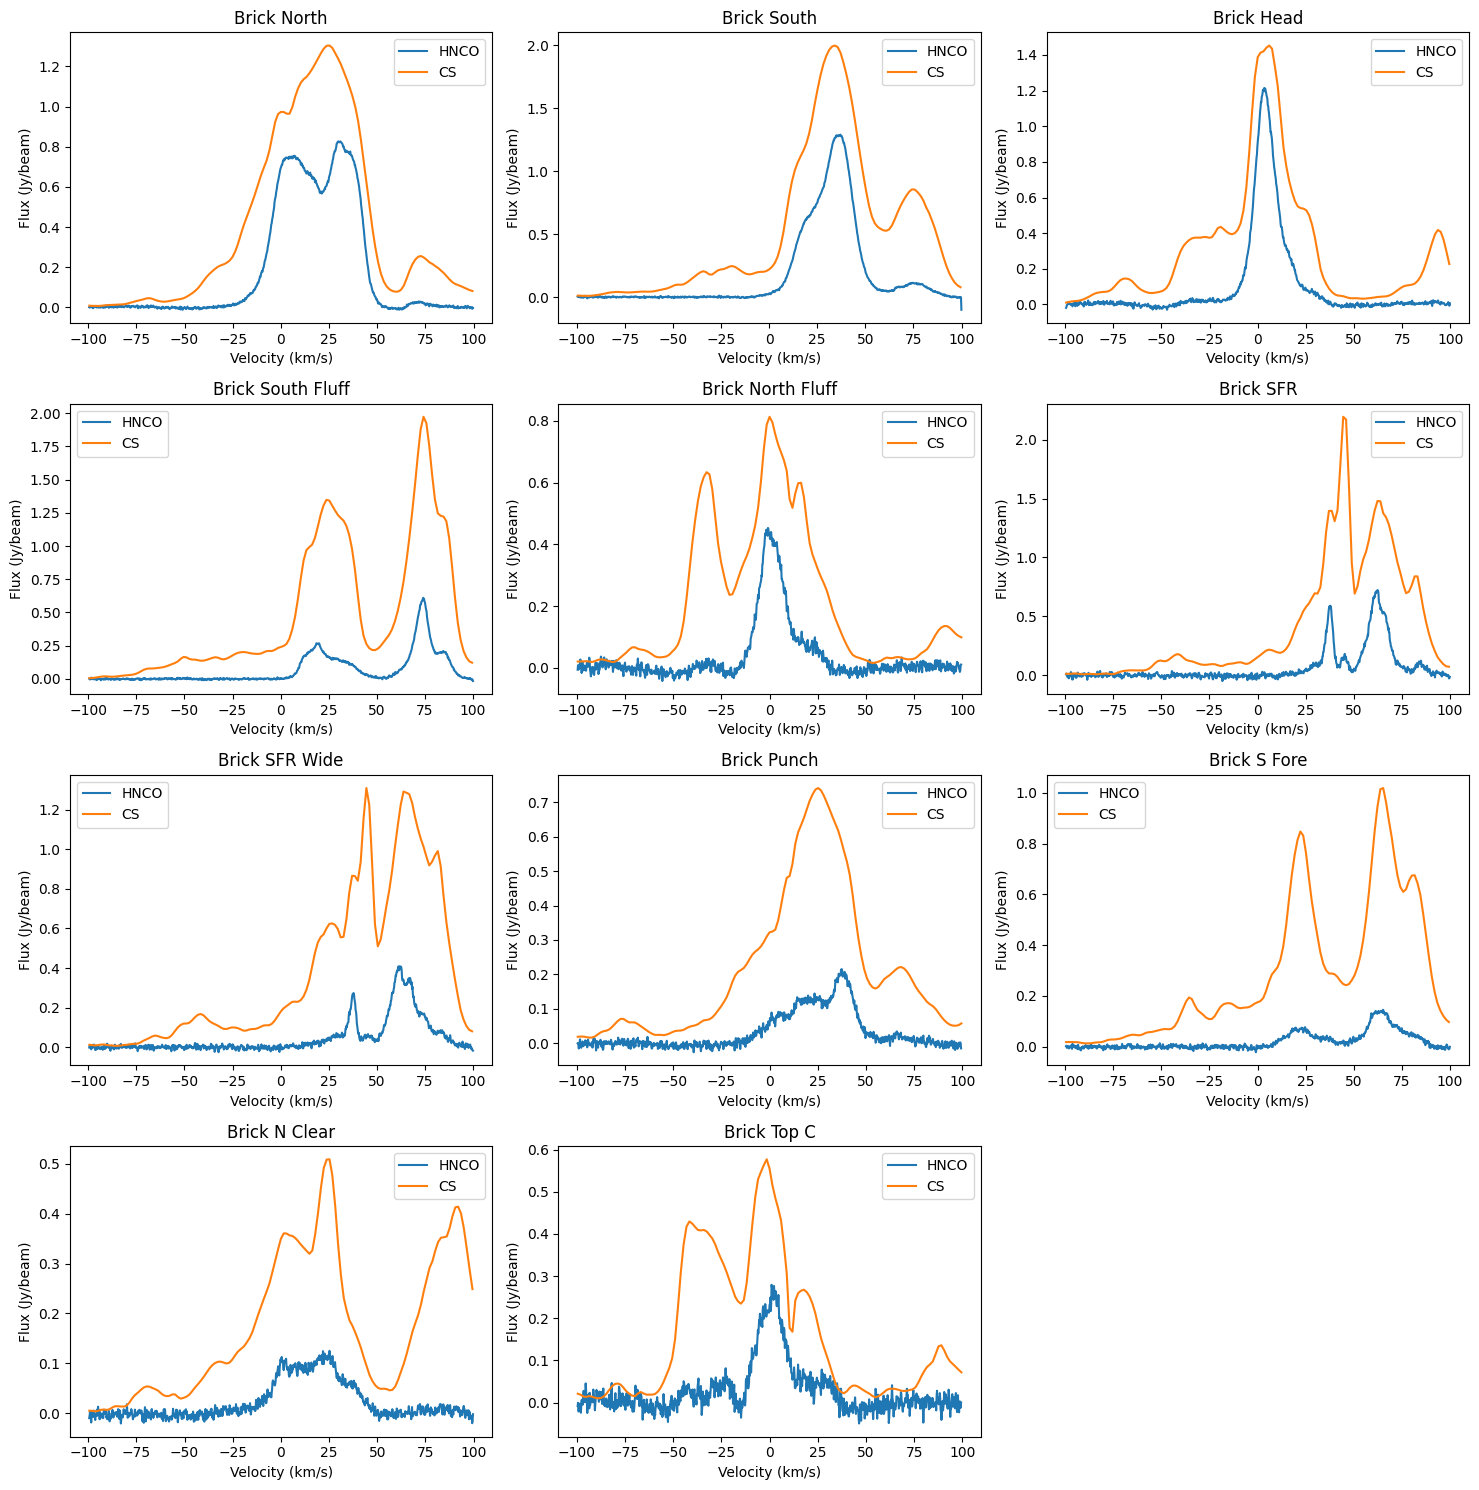

In [100]:
fig, axes = plt.subplots(4, 3, figsize=(15, 15))
for i in range(11):
    ax = axes.flatten()[i]
    spec_HNCO = spectra_brick_HNCO[i]
    spec_CS = spectra_brick_CS[i]
    #spec_SiO = spectra_brick_SiO[i]
    ax.plot(spec_HNCO.spectral_axis.to(u.km/u.s), spec_HNCO.value, label='HNCO')
    ax.plot(spec_CS.spectral_axis.to(u.km/u.s), spec_CS.value, label='CS')
    #ax.plot(spec_SiO.spectral_axis.to(u.km/u.s), spec_SiO.value, label='SiO')
    ax.set_xlabel('Velocity (km/s)')
    ax.set_ylabel('Flux (Jy/beam)')
    ax.set_title(labels_brick[i])
    ax.legend()
plt.tight_layout()

axes.flatten()[-1].axis('off')